# Iteración 1: Enfoque Micro-Biomecánico y Diseño Inicial de la Arquitectura Predictiva

Esta primera iteración establece los cimientos metodológicos del proyecto, partiendo de una hipótesis fundamentada en la literatura científica sobre anticipación deportiva: la dirección de un penalti está intrínsecamente ligada a señales cinemáticas observables en el cuerpo del lanzador durante los instantes previos y simultáneos al golpeo. Bajo esta premisa, se postula que un modelo de visión artificial es capaz de extraer estas señales directamente de los fotogramas del vídeo. En esta fase embrionaria, el motor seleccionado es **Qwen2.5-VL-7B**, cuya función no es emitir un pronóstico final sobre la trayectoria del balón, sino actuar como un extractor intermedio de características, transformando la secuencia de imágenes en una memoria textual estructurada cronológicamente.

El diseño de esta extracción visual adopta un enfoque estrictamente **micro-biomecánico**. Apoyándose en la lógica del movimiento, el sistema interroga a la red neuronal sobre variables anatómicas de alta granularidad: el ángulo exacto de aproximación, la rotación de la planta del pie de apoyo, la inclinación milimétrica del tronco, la alineación entre la pelvis y el torso, la zona aparente de contacto bota-balón y el vector inicial del seguimiento.  Para preservar la dinámica temporal de la cadena cinética, esta información se segmenta en fases (carrera, apoyo, impacto y seguimiento) y se concatena posteriormente en una única memoria global que captura la progresión del gesto.

Para determinar la mejor forma de interactuar con el VLM, el diseño experimental de esta fase bifurca la extracción en dos paradigmas de *prompting* bajo una regla inquebrantable: el modelo debe limitarse a describir la evidencia visual, sin intentar deducir la táctica ni la dirección final.
* **Variante de Prompts Abiertos:** El VLM redacta una descripción técnica y libre, permitiendo la captura de matices espaciales complejos y expresando la incertidumbre de forma natural mediante fórmulas léxicas como "parece" o "aparenta".
* **Variante de Prompts Cerrados:** Se fuerza al modelo a clasificar cada micro-variable en un catálogo discreto y rígido de etiquetas (por ejemplo, catalogando el pie de apoyo exclusivamente como `hacia_delante`, `ligeramente_abierta` o `muy_abierta`), canalizando la duda a través de la etiqueta explícita `INCIERTO`. El objetivo de esta vía es erradicar la variabilidad lingüística y homogeneizar la matriz de datos.

Una vez consolidada la memoria visual intermedia, el conducto de inferencia delega el razonamiento final a un segundo Modelo de Lenguaje (probando arquitecturas como Qwen3-8B, DeepSeek-R1-7B y Llama-3.1-8B). Durante estas primeras pruebas se documentó un hallazgo arquitectónico crítico: solicitar al LLM una predicción en el espacio absoluto de la portería (`IZQUIERDA`, `CENTRO`, `DERECHA`) provocaba alucinaciones espaciales severas debido a la perspectiva diagonal de la cámara televisiva. En consecuencia, el sistema fue recalibrado para razonar exclusivamente en el espacio anatómico relativo al jugador (`CRUZADO`, `CENTRAL`, `ABIERTO`), externalizando la traducción a coordenadas absolutas mediante un mapeo de *software* determinista basado en la lateralidad del lanzador.

En síntesis, esta primera iteración ejerce como fase exploratoria y de calibración. A través de la evaluación de diferentes temperaturas de generación —buscando el equilibrio entre repetibilidad determinista y diversidad descriptiva—, se asienta el *pipeline* modular que regirá todo el proyecto (extracción visual por fases $\rightarrow$ memoria intermedia $\rightarrow$ inferencia textual relativa). Los resultados de este bloque inicial servirán como línea base para determinar si un análisis micro-biomecánico de tan alta resolución es empíricamente viable frente al ruido y la compresión inherentes al *dataset*.

### 1. Configuración base y motor de procesamiento visual

Para establecer los cimientos técnicos del sistema y asegurar una base sólida tanto para esta primera iteración como para los desarrollos posteriores, se configuró inicialmente el entorno de trabajo importando librerías de procesamiento de imagen como OpenCV y NumPy, junto con herramientas de gestión de datos como Pandas. En esta misma sección se inicializó el cliente de OpenAI apuntando al puerto local del servidor en LM Studio con la clave de API correspondiente. Como el envío de un vídeo completo en bruto saturaría los límites de contexto del modelo de visión (VLM) e introduciría ruido visual innecesario, se propuso diseñar un motor de extracción y transformación que segmenta la acción y optimiza las imágenes antes de realizar cualquier llamada a la API.

Para corregir las diferencias temporales que surgen debido a que los vídeos originales tienen duraciones variables, se desarrollaron las funciones `get_correct_bbox` y `get_kick_frame_idx` con el objetivo de sincronizar perfectamente cada fotograma con su correspondiente registro tabular en el archivo CSV. En la función encargada del fotograma del impacto, se localiza la fila exacta donde la variable del golpeo es igual a uno y, mediante una lógica de desvíos matemáticos basada en una longitud objetivo de 64 fotogramas, se calcula un índice modificado que se mantiene dentro de los límites estrictos del vídeo. De una manera muy similar, para recuperar la caja delimitadora espacial del jugador en un instante concreto, se recalcula el índice real adaptándolo al tamaño de la secuencia modificada y se extraen las coordenadas enteras de origen, ancho y alto del operario en ese momento exacto.

Para aislar la silueta del tirador y eliminar elementos irrelevantes del fondo como la portería o el público, se implementó el método `crop_frame`, el cual se encarga de realizar el recorte físico del fotograma. Esta función aprovecha las coordenadas espaciales obtenidas previamente y establece una ventana de corte definida por unos límites que se controlan mediante las funciones de mínimo y máximo de Python para no exceder la resolución nativa de la imagen. Dentro de este proceso, se añade un margen dinámico de seguridad de 100 píxeles a cada lado de la caja delimitadora, y esto se hace específicamente para evitar que los brazos o la pierna de golpeo queden cortados en las fases del tiro que presentan una mayor amplitud articular o movimientos balísticos explosivos.

Para adaptar los recortes resultantes a las restricciones de entrada de la red sin alterar las proporciones originales del cuerpo del futbolista, se diseñó la función de reescalado geométrico `resize_keep_aspect_ratio`. Este método calcula de forma matemática el factor de escala idóneo para ajustar la imagen a una resolución estándar de 384x384 píxeles y aplica una interpolación de área de OpenCV si se está reduciendo el tamaño, o una interpolación cúbica si es necesario ampliarlo. Para evitar la deformación postural que arruinaría el posterior análisis cinemático, se calcula la diferencia en píxeles que falta para cubrir el tamaño objetivo, se divide ese residuo equitativamente mediante una división entera y se utiliza la función `copyMakeBorder` para añadir franjas negras constantes alrededor del recorte del jugador.

Para estructurar temporalmente el lanzamiento del penalti respetando la secuencia cronológica real del gesto, se creó la función orquestadora `extract_frames_by_phase`. Este componente abre el archivo de vídeo con un objeto de captura de OpenCV, almacena todos sus fotogramas en una lista indexada y toma el índice del impacto como punto de referencia central para establecer cuatro intervalos dinámicos fijos: la carrera inicial desde el fotograma cero, la carrera de aproximación crítica delimitada por los 12 fotogramas previos al golpeo, el momento del impacto exacto en una ventana estrecha de tres fotogramas y el seguimiento posterior de la inercia. Como el número de imágenes por fase sigue siendo demasiado elevado, se introduce la función `sample_frames_from_range`, que calcula índices equidistantes mediante un mapeo entero proporcional al número de muestras deseadas. Finalmente, cada fotograma seleccionado se comprime en formato JPEG con una calidad del 95% mediante `imencode` y se transforma en una cadena de texto codificada en base64 para su correcto envío a través del protocolo de la API.

In [ ]:
import cv2
import base64
import os
import time
import pandas as pd
from openai import OpenAI
import matplotlib.pyplot as plt
import numpy as np

CLIENT = OpenAI(base_url="http://localhost:1234/v1", api_key="lm-studio")

BASE_DIR = r'C:\Users\david\OneDrive\Desktop\TFT_LLMPenalties2026'
CSV_ORIGINAL_PATH = os.path.join(BASE_DIR, 'labeled_frames_cuttedvids.csv')
CSV_GROUPED_PATH = os.path.join(BASE_DIR, 'labeled_frames_grouped.csv')
VIDEOS_DIR = os.path.join(BASE_DIR, 'modified_videos')
RESULTADOS_MEMORIA_PATH = os.path.join(BASE_DIR, 'memorias_visuales.csv')
DF_ORIGINAL = pd.read_csv(CSV_ORIGINAL_PATH)

def resize_keep_aspect_ratio(image, target_size=384):
    """ Escala una imagen sin deformarla y añade franjas negras """
    old_h, old_w = image.shape[:2]
    ratio = min(target_size / old_w, target_size / old_h)
    new_w = int(old_w * ratio)
    new_h = int(old_h * ratio)
    
    if ratio < 1.0:
        interp = cv2.INTER_AREA
    else:
        interp = cv2.INTER_CUBIC
        
    resized = cv2.resize(image, (new_w, new_h), interpolation=interp)
    
    delta_w = target_size - new_w
    delta_h = target_size - new_h
    top, bottom = delta_h // 2, delta_h - (delta_h // 2)
    left, right = delta_w // 2, delta_w - (delta_w // 2)
    
    padded_img = cv2.copyMakeBorder(resized, top, bottom, left, right, 
                                    cv2.BORDER_CONSTANT, value=[0, 0, 0])
    return padded_img

def encode_image_to_base64(frame):
    _, buffer = cv2.imencode('.jpg', frame, [int(cv2.IMWRITE_JPEG_QUALITY), 95])
    return base64.b64encode(buffer).decode('utf-8')

def get_correct_bbox(vid_data, frame_idx_modificado, target_frames=64):
    total_original_frames = len(vid_data)
    if total_original_frames == 0: return None
    if total_original_frames > target_frames:
        indice_real = frame_idx_modificado + (total_original_frames - target_frames)
    elif total_original_frames < target_frames:
        padding_size = target_frames - total_original_frames
        indice_real = 0 if frame_idx_modificado < padding_size else frame_idx_modificado - padding_size
    else:
        indice_real = frame_idx_modificado
    indice_real = min(indice_real, len(vid_data) - 1)
    return int(vid_data.iloc[indice_real]['BB_x']), int(vid_data.iloc[indice_real]['BB_y']), int(vid_data.iloc[indice_real]['BB_w']), int(vid_data.iloc[indice_real]['BB_h'])

def get_kick_frame_idx(vid_data, target_frames=64):
    total_orig = len(vid_data)
    kick_rows = vid_data[vid_data['kick_frame'] == 1]
    kick_orig = int(kick_rows.iloc[0]['frame_id']) if len(kick_rows) > 0 else total_orig // 2

    if total_orig > target_frames:
        kick_mod = kick_orig - (total_orig - target_frames)
    elif total_orig < target_frames:
        kick_mod = kick_orig + (target_frames - total_orig)
    else:
        kick_mod = kick_orig

    total_mod = min(total_orig, target_frames)
    return max(0, min(total_mod - 1, kick_mod))

def crop_frame(frame, vid_data, frame_idx, target_frames=64, pad=100):
    """ Recorta el jugador usando el Bounding Box y añade un margen de padding dinámico """
    bbox = get_correct_bbox(vid_data, frame_idx, target_frames=target_frames)
    if bbox:
        x, y, w, h = bbox
        H, W, _ = frame.shape
        x1, y1 = max(0, x - pad), max(0, y - pad)
        x2, y2 = min(W, x + w + pad), min(H, y + h + pad)
        return resize_keep_aspect_ratio(frame[y1:y2, x1:x2], target_size=384)
    return resize_keep_aspect_ratio(frame, target_size=512)

def sample_frames_from_range(frames, vid_data, start, end, n_samples):
    segment = list(range(start, end))
    if not segment: return []
    if len(segment) <= n_samples:
        indices = segment
    else:
        indices = [segment[int(i * len(segment) / n_samples)] for i in range(n_samples)]
    return [encode_image_to_base64(crop_frame(frames[i], vid_data, i)) for i in indices]

def extract_frames_by_phase(video_path, vid_data, n_carrera_1=4, n_carrera_2=6, n_impacto=3, n_seguimiento=6):
    cap = cv2.VideoCapture(video_path)
    frames = []
    while True:
        ret, frame = cap.read()
        if not ret: break
        frames.append(frame)
    cap.release()
    if not frames: return None

    kick_idx = get_kick_frame_idx(vid_data)
    total = len(frames)
    
    fase_carrera_1   = (0, max(1, kick_idx - 12))
    
    fase_carrera_2   = (max(1, kick_idx - 12), max(2, kick_idx - 1))
    
    fase_impacto     = (max(0, kick_idx - 1), min(total, kick_idx + 2))
    
    fase_seguimiento = (min(total, kick_idx + 2), total)

    return {
        "carrera_1":     sample_frames_from_range(frames, vid_data, *fase_carrera_1,   n_carrera_1),
        "carrera_2":     sample_frames_from_range(frames, vid_data, *fase_carrera_2,   n_carrera_2),
        "impacto":       sample_frames_from_range(frames, vid_data, *fase_impacto,     n_impacto),
        "seguimiento":   sample_frames_from_range(frames, vid_data, *fase_seguimiento, n_seguimiento),
        "kick_idx":      kick_idx,
        "total":         total,
        "n_carrera_1":   n_carrera_1,
        "n_carrera_2":   n_carrera_2,
        "n_impacto":     n_impacto,
        "n_seguimiento": n_seguimiento,
    }

### 2. Generación de la Memoria Visual: Enfoque Micro-biomecánico (Prompts Abiertos)

Para transformar los fotogramas preprocesados en una representación textual estructurada sin predecir directamente la zona de disparo, se implementó la función principal `generar_memoria_visual`. En lugar de actuar como un predictor final, se utilizó el modelo multimodal **Qwen2.5-VL-7B** como un extractor intermedio de características micro-biomecánicas. Este modelo de visión-lenguaje de 7 mil millones de parámetros destaca por su avanzada capacidad para procesar secuencias de imágenes temporalmente ordenadas y comprender relaciones espaciales complejas, lo que resulta idóneo para analizar la geometría corporal del lanzador. A través de una estrategia de prompts abiertos, se otorgó a esta red neuronal cierto margen descriptivo para recoger matices espaciales sutiles en la postura del jugador.

Para definir el comportamiento estricto del modelo y evitar alucinaciones narrativas, se diseñó un prompt de sistema base (`prompt_sistema_fase`). En esta instrucción se obliga al VLM a actuar exclusivamente como un observador técnico de geometría corporal especializado en penaltis, prohibiendo explícitamente cualquier deducción táctica, interpretación de intenciones o predicción del tiro. Para gestionar adecuadamente la incertidumbre visual causada por la perspectiva diagonal de la cámara, el desenfoque de movimiento o las oclusiones, se instruyó al sistema para canalizar las dudas utilizando fórmulas probabilísticas obligatorias como "parece", "aparenta" o "difícil de apreciar". Además, dentro de esta misma configuración, se inyecta dinámicamente la lateralidad del jugador para adaptar el contexto a su pierna hábil y a su pie de apoyo de forma automática.

Para guiar la atención del modelo hacia las señales biomecánicas más relevantes, se redactaron cuatro prompts de usuario independientes correspondientes a cada fase del movimiento. En la secuencia de la carrera inicial, se le pide evaluar el ángulo de aproximación espacial y la alineación tronco-cadera; en la plantada previa al golpeo, la extracción se enfoca estrictamente en hacia dónde apunta el pie de apoyo respecto al balón y la inclinación del tronco; durante el fotograma crítico del impacto, debe analizar la rotación relativa del bloque pélvico-torácico y la zona aparente de contacto bota-balón; finalmente, en el seguimiento posterior, evalúa la dirección inicial de la rodilla y la inercia de la pierna para determinar el cierre o apertura del gesto.

Para enviar estas peticiones a la red multimodal, se definió la función interna `llamar_vlm`, la cual empaqueta los prompts textuales junto con el arreglo de imágenes codificadas en base64 y ejecuta la llamada al servidor local a través del cliente. Para asegurar que las descripciones resultantes sean lo más estables y repetibles posibles frente a la misma secuencia de imágenes, minimizando la creatividad intrínseca del lenguaje, se configuró el parámetro de temperatura con un valor bajo (`temperature=0.3`), limitando además la salida a un máximo de 800 tokens para garantizar descripciones concisas y directas.

Para consolidar toda esta información visual interpretada en un formato útil de cara a la etapa de inferencia lingüística, se implementó el método auxiliar `construir_memoria_estructurada`. Esta función recibe las cuatro descripciones generadas de forma independiente, aplica una limpieza de formato mediante la instrucción `strip`, gestiona posibles caídas del servidor insertando un texto de error por defecto y concatena los resultados junto a sus respectivos encabezados descriptivos (por ejemplo, `--- FASE DE IMPACTO ---`). Esto se hace para ensamblar un único bloque de texto jerárquico que conserva perfectamente la progresión cronológica del movimiento original, permitiendo que el modelo de lenguaje posterior analice la mecánica completa de la acción sin perder el orden temporal de los eventos corporales.

In [3]:
import pandas as pd

def construir_memoria_estructurada(desc_carrera_1, desc_carrera_2, desc_impacto, desc_seguimiento):
    def limpiar(texto):
        return texto.strip() if texto else "No se pudo extraer información."

    return (
        f"--- FASE DE CARRERA INICIAL ---\n{limpiar(desc_carrera_1)}\n\n"
        f"--- FASE DE PLANTA/APOYO ---\n{limpiar(desc_carrera_2)}\n\n"
        f"--- FASE DE IMPACTO ---\n{limpiar(desc_impacto)}\n\n"
        f"--- FASE DE SEGUIMIENTO E INERCIA ---\n{limpiar(desc_seguimiento)}"
    )


def generar_memoria_visual(video_path, vid_data, pierna):
    fases = extract_frames_by_phase(video_path, vid_data)
    if not fases:
        return None

    def llamar_vlm(frames_b64, prompt_sistema, prompt_usuario):
        if not frames_b64:
            return "No hay frames."

        content = [{"type": "text", "text": prompt_usuario}]
        for img in frames_b64:
            content.append({
                "type": "image_url",
                "image_url": {"url": f"data:image/jpeg;base64,{img}"}
            })

        try:
            response = CLIENT.chat.completions.create(
                model="local-model",
                messages=[
                    {"role": "system", "content": prompt_sistema},
                    {"role": "user", "content": content}
                ],
                max_tokens=800,
                temperature=0.3
            )
            return response.choices[0].message.content
        except Exception as e:
            return f"Error visual: {e}"

    pierna = pierna.lower().strip()
    pie_apoyo = "izquierdo" if pierna == "derecha" else "derecho"

    prompt_sistema_fase = f"""
Eres un analista biomecánico de visión artificial especializado en penaltis de fútbol.

Analizas a un jugador pateando un penalti con la pierna {pierna.upper()}, visto desde una cámara diagonal trasera.

Tu tarea es describir únicamente variables micro-biomecánicas visualmente observables en la secuencia de imágenes. 
Debes actuar como un observador técnico de geometría corporal, no como un narrador, un comentarista ni un analista táctico.

Debes priorizar estas señales:
- ángulo de aproximación al balón,
- lateralidad visible de la entrada respecto al balón,
- orientación del pie de apoyo,
- posición relativa del pie de apoyo respecto al balón,
- inclinación del tronco,
- orientación relativa de tronco y pelvis,
- configuración visible de la pierna de golpeo,
- zona aparente de contacto bota-balón,
- seguimiento inmediato y dirección inicial de la pierna tras el impacto.

Reglas obligatorias:
- Describe solo lo que esté respaldado visualmente por los fotogramas.
- No inventes detalles anatómicos ocultos, fuerzas, ni trayectorias no visibles.
- No uses biomecánica teórica para rellenar huecos.
- No hables de la intención del lanzador ni predigas directamente la dirección final del disparo.
- Evita comentarios generales como "el jugador parece preparado" o "la postura es natural".
- Si una señal es ambigua por perspectiva, desenfoque, oclusión o resolución, exprésalo con fórmulas como "parece", "aparenta", "difícil de apreciar" o "(estimación)".
- Usa vocabulario técnico, concreto y breve.
- Prioriza la descripción de relaciones espaciales finas entre segmentos corporales y balón.
""".strip()

    prompt_carrera_1 = """
Observa esta secuencia correspondiente a la fase inicial de la carrera de aproximación.

Describe en texto técnico y breve únicamente estos aspectos micro-biomecánicos:

1. Ángulo de aproximación (APA):
Indica desde qué lado visual del balón entra el jugador y describe si la trayectoria hacia el balón parece recta, ligeramente diagonal o marcadamente diagonal.

2. Asimetría espacial de la entrada:
Describe si la aproximación genera una entrada visual más cerrada o más abierta respecto al eje balón-portería.
No interpretes la intención del disparo; limítate a la geometría visible.

3. Alineación tronco-cadera durante la aproximación:
Describe si el tronco se mantiene relativamente vertical o si presenta una inclinación anterior progresiva.
Indica también si pelvis y tronco aparentan mantenerse alineados o si ya se aprecia una ligera pre-rotación.

4. Configuración micro-postural de la carrera:
Describe si la base corporal aparenta ser compacta o abierta y si el centro corporal parece mantenerse alto o descender ligeramente al acercarse al balón.

5. Preparación del apoyo:
Describe cualquier señal visible de precolocación corporal relevante para la futura plantada, especialmente en la relación entre la pierna de golpeo, el eje del tronco y la llegada al balón.

No añadas conclusiones sobre la dirección del tiro.
No conviertas esta fase en una descripción macro-gestual.
""".strip()

    prompt_carrera_2 = f"""
Observa la secuencia correspondiente a la fase de planta/apoyo inmediatamente previa al impacto.

Describe en texto técnico y breve únicamente estos aspectos:

1. Dirección final de llegada:
Confirma desde qué lado visual se produce la llegada al balón en la plantada y si la entrada final mantiene una geometría recta, ligeramente diagonal o marcadamente diagonal.

2. Orientación del pie de apoyo ({pie_apoyo.upper()}):
Describe hacia dónde parece apuntar la punta del pie de apoyo.
Distingue, si es posible, entre orientación hacia delante, ligeramente abierta hacia fuera o claramente abierta hacia fuera.
Ten en cuenta la distorsión de la cámara diagonal trasera y no sobreafirmes si la imagen es ambigua.

3. Posición del pie de apoyo respecto al balón:
Describe si el pie de apoyo parece quedar retrasado, alineado o adelantado respecto al centro del balón.
Indica también, si puede apreciarse, si queda más próximo o más separado lateralmente del balón.

4. Inclinación del tronco en la plantada:
Describe si el tronco cae hacia delante sobre el balón, permanece relativamente vertical o presenta inclinación lateral apreciable.

5. Orientación pre-impacto de pelvis y torso:
Describe si el bloque pélvico-torácico parece alineado hacia delante o si aparenta una apertura hacia el exterior.
Si pelvis y torso no parecen coincidir exactamente, descríbelo.

6. Asimetría corporal previa al golpeo:
Describe si la disposición apoyo-golpeo aparenta una organización más cerrada, neutra o abierta desde el punto de vista espacial.

No hables todavía del seguimiento posterior.
No uses lenguaje narrativo.
""".strip()

    prompt_impacto = f"""
Observa exclusivamente el frame exacto del contacto pie-balón.

Describe en texto técnico y breve únicamente estos aspectos micro-biomecánicos:

1. Inclinación del tronco en impacto:
Indica si el tronco cae hacia delante, se mantiene relativamente vertical o aparenta una inclinación posterior o lateral.

2. Rotación relativa de tronco y pelvis:
Fíjate en el bloque tronco-pelvis en el instante de golpeo.
Describe si parecen orientados hacia delante o si visualmente se aprecian abiertos hacia el exterior.
Si uno de los dos segmentos aparenta mayor rotación que el otro, indícalo.

3. Configuración articular visible de la pierna de golpeo ({pierna.upper()}):
Describe la disposición visible de cadera, rodilla y pie en el momento del contacto, pero solo en términos observables.
No inventes ángulos exactos si no pueden verse.

4. Zona aparente de contacto bota-balón:
Si la imagen lo permite, indica si el contacto parece producirse con la zona interna, central o externa de la bota.
Si no se aprecia bien, dilo explícitamente.

5. Relación entre apoyo e impacto:
Describe si el conjunto pie de apoyo - pelvis - pierna de golpeo aparenta una ejecución visualmente más cerrada, neutra o abierta.

6. Asimetría espacial en el instante crítico:
Describe si la organización corporal en el contacto parece favorecer una salida corporal alineada o una apertura lateral visible.
No deduzcas la dirección final del balón.

No expliques biomecánica teórica.
No extraigas conclusiones tácticas.
""".strip()

    prompt_seguimiento = f"""
Observa únicamente la fase inmediatamente posterior al impacto.

Describe en texto técnico y breve únicamente estos aspectos:

1. Dirección inicial del seguimiento de la pierna de golpeo ({pierna.upper()}):
Describe si la pierna continúa hacia delante, cruza hacia dentro o sale abierta hacia fuera tras el impacto.

2. Dirección visible de la rodilla tras el golpeo:
Indica si la rodilla parece orientarse hacia el frente, hacia dentro o mantenerse abierta hacia fuera.

3. Continuidad de la rotación pélvica:
Describe si la pelvis aparenta seguir acompañando el gesto hacia delante o si el seguimiento conserva una apertura lateral visible.

4. Cierre o apertura inmediata del gesto:
Describe si el seguimiento inmediato sugiere un cierre cruzado del gesto o una continuidad más abierta hacia el exterior.

5. Altura relativa del pie de golpeo:
Describe si el pie asciende claramente, se mantiene a media altura o queda relativamente bajo.

No describas la inercia general del cuerpo salvo que sea necesaria para explicar la dirección de la pierna de golpeo.
No conviertas esta fase en un análisis macro-gestual.
""".strip()

    desc_carrera_1 = llamar_vlm(
        fases["carrera_1"],
        prompt_sistema_fase,
        prompt_carrera_1
    )

    desc_carrera_2 = llamar_vlm(
        fases["carrera_2"],
        prompt_sistema_fase,
        prompt_carrera_2
    )

    desc_impacto = llamar_vlm(
        fases["impacto"],
        prompt_sistema_fase,
        prompt_impacto
    )

    desc_seguimiento = llamar_vlm(
        fases["seguimiento"],
        prompt_sistema_fase,
        prompt_seguimiento
    )

    return {
        "final": construir_memoria_estructurada(
            desc_carrera_1,
            desc_carrera_2,
            desc_impacto,
            desc_seguimiento
        )
    }

### 3. Generación de la Memoria Visual: Enfoque Micro-biomecánico (Prompts Cerrados)

Para reducir la variabilidad lingüística inherente al enfoque descriptivo y generar memorias visuales mucho más homogéneas y estandarizadas entre los diferentes vídeos, se implementó en esta celda la segunda variante metodológica de la iteración. En lugar de permitir la redacción de texto libre, se utilizó nuevamente el modelo Qwen2.5 para que actuara estrictamente como un clasificador técnico, encasillando cada variable micro-biomecánica dentro de un conjunto discreto de categorías predefinidas. 

Para forzar este cambio de rol algorítmico, se reescribió por completo el comportamiento base en el `prompt_sistema_fase`. En esta nueva instrucción se prohíbe explícitamente al modelo añadir justificaciones, explicaciones o cualquier tipo de texto narrativo adicional, obligándolo a ceñirse en exclusiva a devolver un formato estricto de clave-valor. Al igual que en la variante anterior, se inyectó la lateralidad del lanzador para contextualizar el análisis, pero esta vez exigiendo que la red se comporte como una función de mapeo directo entre las características extraídas de la imagen y una lista cerrada de opciones permitidas.

Para estructurar la extracción de características en cada fase del movimiento, se diseñaron peticiones específicas que traducen las señales cinemáticas a diccionarios de etiquetas concretas. Por ejemplo, al evaluar la secuencia de la plantada, la orientación del pie de apoyo solo puede clasificarse como `HACIA_DELANTE`, `LIGERAMENTE_ABIERTO` o `MUY_ABIERTO`, mientras que el contacto de la bota en el fotograma crítico debe etiquetarse obligatoriamente como `INTERIOR`, `CENTRAL` o `EXTERIOR`. Esto se hace para facilitar enormemente el procesamiento computacional posterior por parte del LLM inferencial, ya que el texto resultante abandona la ambigüedad narrativa y adopta una estructura casi tabular.

Para gestionar de forma rigurosa la incertidumbre en el análisis de vídeo desde una cámara diagonal trasera, donde la oclusión corporal o el desenfoque son limitaciones frecuentes, se introdujo un mecanismo de seguridad crítico en todas las variables evaluadas: la etiqueta obligatoria de escape `INCIERTO`. De esta manera, se evita de raíz que el modelo infiera o alucine información geométrica cuando la señal visual es ambigua, canalizando las dudas hacia una categoría específica y reconociendo sus limitaciones perceptivas sin contaminar la memoria con datos espaciales falsos.

Para ejecutar y ensamblar estas clasificaciones, se mantuvo la arquitectura base de comunicación a través de la función `llamar_vlm`, preservando la temperatura baja (`temperature=0.3`) para maximizar el determinismo en la selección de las etiquetas. Finalmente, para preparar los datos de cara a la etapa de razonamiento táctico, se reutilizó el método `construir_memoria_estructurada`, el cual toma cada bloque de etiquetas generadas de forma aislada y las concatena limpiamente, manteniendo el orden cronológico inalterado de la acción (desde la carrera inicial hasta la inercia del seguimiento).

In [2]:
import pandas as pd

def construir_memoria_estructurada(desc_carrera_1, desc_carrera_2, desc_impacto, desc_seguimiento):
    def limpiar(texto):
        return texto.strip() if texto else "No se pudo extraer información."

    return (
        f"--- FASE DE CARRERA INICIAL ---\n{limpiar(desc_carrera_1)}\n\n"
        f"--- FASE DE PLANTA/APOYO ---\n{limpiar(desc_carrera_2)}\n\n"
        f"--- FASE DE IMPACTO ---\n{limpiar(desc_impacto)}\n\n"
        f"--- FASE DE SEGUIMIENTO E INERCIA ---\n{limpiar(desc_seguimiento)}"
    )


def generar_memoria_visual(video_path, vid_data, pierna):
    fases = extract_frames_by_phase(video_path, vid_data)
    if not fases:
        return None

    def llamar_vlm(frames_b64, prompt_sistema, prompt_usuario):
        if not frames_b64:
            return "No hay frames."

        content = [{"type": "text", "text": prompt_usuario}]
        for img in frames_b64:
            content.append({
                "type": "image_url",
                "image_url": {"url": f"data:image/jpeg;base64,{img}"}
            })

        try:
            response = CLIENT.chat.completions.create(
                model="local-model",
                messages=[
                    {"role": "system", "content": prompt_sistema},
                    {"role": "user", "content": content}
                ],
                max_tokens=800,
                temperature=0.3
            )
            return response.choices[0].message.content
        except Exception as e:
            return f"Error visual: {e}"

    pierna = pierna.lower().strip()
    pie_apoyo = "izquierdo" if pierna == "derecha" else "derecho"

    prompt_sistema_fase = f"""
Eres un analista biomecánico de visión artificial especializado en penaltis de fútbol.

Analizas a un jugador pateando un penalti con la pierna {pierna.upper()}, visto desde una cámara diagonal trasera.

Tu tarea es clasificar únicamente variables micro-biomecánicas visualmente observables en la secuencia de imágenes.
Debes actuar como un clasificador técnico de geometría corporal.

Variables prioritarias:
- ángulo de aproximación,
- lateralidad visible de entrada,
- orientación del pie de apoyo,
- posición relativa del pie de apoyo respecto al balón,
- inclinación del tronco,
- orientación de pelvis y torso,
- configuración visible de la pierna de golpeo,
- zona aparente de contacto bota-balón,
- dirección inicial del seguimiento tras el impacto.

Reglas obligatorias:
- Usa solo las etiquetas permitidas.
- Devuelve exactamente el formato pedido.
- No añadas explicaciones, justificaciones ni texto extra.
- No hables de intención de disparo.
- No predigas la dirección final del balón.
- Si la imagen es ambigua, usa la categoría más probable visualmente.
- Solo usa INCIERTO cuando la señal sea realmente imposible de clasificar.
""".strip()

    prompt_carrera_1 = """
Observa esta secuencia correspondiente a la fase inicial de la carrera de aproximación.

Clasifica usando exactamente este formato:

APA: <etiqueta>
ENTRADA_LATERAL: <etiqueta>
TRONCO_CARRERA: <etiqueta>
PRE_ROTACION_TRONCO_PELVIS: <etiqueta>
BASE_CARRERA: <etiqueta>

Etiquetas permitidas:

APA = FRONTAL | LIGERAMENTE_DIAGONAL | MARCADAMENTE_DIAGONAL | INCIERTO
ENTRADA_LATERAL = IZQUIERDA_VISUAL | DERECHA_VISUAL | CENTRADA | INCIERTO
TRONCO_CARRERA = ERGUIDO | LIGERAMENTE_INCLINADO | CLARAMENTE_INCLINADO | INCIERTO
PRE_ROTACION_TRONCO_PELVIS = CERRADA | NEUTRA | ABIERTA | INCIERTO
BASE_CARRERA = COMPACTA | NEUTRA | ABIERTA | INCIERTO

Devuelve solo esas cinco líneas.
""".strip()

    prompt_carrera_2 = f"""
Observa la secuencia correspondiente a la fase de planta/apoyo inmediatamente previa al impacto.

Clasifica usando exactamente este formato:

LLEGADA_FINAL: <etiqueta>
ORIENTACION_PIE_APOYO: <etiqueta>
POSICION_PIE_APOYO_BALON: <etiqueta>
SEPARACION_LATERAL_APOYO: <etiqueta>
TRONCO_PLANTADA: <etiqueta>
ORIENTACION_TRONCO_PELVIS_PREIMPACTO: <etiqueta>

Etiquetas permitidas:

LLEGADA_FINAL = FRONTAL | LIGERAMENTE_DIAGONAL | MARCADAMENTE_DIAGONAL | INCIERTO
ORIENTACION_PIE_APOYO = HACIA_DELANTE | LIGERAMENTE_ABIERTO | MUY_ABIERTO | INCIERTO
POSICION_PIE_APOYO_BALON = RETRASADO | ALINEADO | ADELANTADO | INCIERTO
SEPARACION_LATERAL_APOYO = CERCANO | INTERMEDIO | SEPARADO | INCIERTO
TRONCO_PLANTADA = ERGUIDO | HACIA_DELANTE | INCLINADO_LATERAL | INCIERTO
ORIENTACION_TRONCO_PELVIS_PREIMPACTO = CERRADA | NEUTRA | ABIERTA | INCIERTO

Devuelve solo esas seis líneas.
Ten en cuenta que el pie de apoyo es el {pie_apoyo.upper()}.
""".strip()

    prompt_impacto = f"""
Observa exclusivamente el frame exacto del contacto pie-balón.

Clasifica usando exactamente este formato:

TRONCO_IMPACTO: <etiqueta>
ROTACION_TRONCO: <etiqueta>
ROTACION_PELVIS: <etiqueta>
PIERNA_GOLPEO_CONFIG: <etiqueta>
CONTACTO_BOTA: <etiqueta>
RELACION_APOYO_GOLPEO: <etiqueta>

Etiquetas permitidas:

TRONCO_IMPACTO = HACIA_DELANTE | VERTICAL | HACIA_ATRAS_O_LATERAL | INCIERTO
ROTACION_TRONCO = CERRADA | NEUTRA | ABIERTA | INCIERTO
ROTACION_PELVIS = CERRADA | NEUTRA | ABIERTA | INCIERTO
PIERNA_GOLPEO_CONFIG = CERRADA | NEUTRA | ABIERTA | INCIERTO
CONTACTO_BOTA = INTERIOR | CENTRAL | EXTERIOR | INCIERTO
RELACION_APOYO_GOLPEO = CERRADA | NEUTRA | ABIERTA | INCIERTO

Devuelve solo esas seis líneas.
La pierna de golpeo es la {pierna.upper()}.
""".strip()

    prompt_seguimiento = f"""
Observa únicamente la fase inmediatamente posterior al impacto.

Clasifica usando exactamente este formato:

DIRECCION_SEGUIMIENTO: <etiqueta>
DIRECCION_RODILLA: <etiqueta>
ROTACION_PELVIS_POST: <etiqueta>
CIERRE_FINAL_GESTO: <etiqueta>
ALTURA_PIE_FINAL: <etiqueta>

Etiquetas permitidas:

DIRECCION_SEGUIMIENTO = HACIA_DELANTE | CRUZADO_HACIA_DENTRO | ABIERTO_HACIA_FUERA | INCIERTO
DIRECCION_RODILLA = FRENTE | HACIA_DENTRO | HACIA_FUERA | INCIERTO
ROTACION_PELVIS_POST = HACIA_DELANTE | NEUTRA | ABIERTA_HACIA_FUERA | INCIERTO
CIERRE_FINAL_GESTO = CERRADO | NEUTRO | ABIERTO | INCIERTO
ALTURA_PIE_FINAL = BAJA | MEDIA | ALTA | INCIERTO

Devuelve solo esas cinco líneas.
La pierna de golpeo es la {pierna.upper()}.
""".strip()

    desc_carrera_1 = llamar_vlm(
        fases["carrera_1"],
        prompt_sistema_fase,
        prompt_carrera_1
    )

    desc_carrera_2 = llamar_vlm(
        fases["carrera_2"],
        prompt_sistema_fase,
        prompt_carrera_2
    )

    desc_impacto = llamar_vlm(
        fases["impacto"],
        prompt_sistema_fase,
        prompt_impacto
    )

    desc_seguimiento = llamar_vlm(
        fases["seguimiento"],
        prompt_sistema_fase,
        prompt_seguimiento
    )

    return {
        "final": construir_memoria_estructurada(
            desc_carrera_1,
            desc_carrera_2,
            desc_impacto,
            desc_seguimiento
        )
    }

### 4. Ejecución del VLM y Generación de Memorias Visuales

Para orquestar el procesamiento en lote del conjunto de vídeos y ejecutar la extracción de características visuales, se implementó esta celda que actúa como el motor principal del sistema. En lugar de ejecutar un bucle iterativo ciego, se diseñó una arquitectura robusta orientada a mitigar la alta exigencia computacional inherente a la inferencia multimodal, previniendo así la pérdida de datos ante posibles interrupciones, cuelgues o picos de saturación de memoria en el servidor local de LM Studio.

Para evitar la duplicación de carga computacional frente a cualquier fallo del sistema, se desarrolló un mecanismo de reanudación automática, conocido técnicamente como *checkpointing*. En primer lugar, el código verifica a nivel de sistema operativo si ya existe el archivo CSV de destino. Si es así, se cargan en memoria los identificadores de los vídeos que ya han sido analizados exitosamente y se filtran dinámicamente del conjunto agrupado, aislando únicamente los archivos pendientes para componer una cola de trabajo eficiente.

Para asegurar que el modelo de visión recibe la información con un contexto temporal y biomecánico impecable, se procede a la preparación dinámica de los datos en cada iteración. Se extrae la información posicional del vídeo en curso desde el registro original y se ordena estrictamente en función de su identificador temporal de fotograma (`frame_id`). Dentro de este mismo paso, se evalúa la variable que codifica la pierna del lanzador (`kicker_foot`) para traducirla a su representación textual, inyectándola automáticamente en la función de generación visual para que el *prompt* se adapte a la lateralidad real del jugador en cada penalti.

Para garantizar la persistencia de las memorias visuales generadas sin acumular un volumen de datos insostenible en la memoria RAM, se configuró una estrategia de guardado incremental. Tras la validación de cada respuesta del modelo, el resultado se transforma en un objeto *DataFrame* y se anexa inmediatamente al archivo físico mediante el modo de escritura de adición (`mode='a'`), protegiendo la integridad de todo el trabajo previo si un vídeo posterior produce un error fatal. Finalmente, para mantener la estabilidad térmica y de memoria del servidor local, se introdujo una pausa forzada de un segundo entre cada petición, lo que otorga el margen de tiempo necesario para que el sistema libere los tensores de la VRAM antes de ingerir el siguiente bloque masivo de imágenes en base64.

In [8]:
df_agrupado = pd.read_csv(CSV_GROUPED_PATH)
procesados_memoria = set()

if os.path.exists(RESULTADOS_MEMORIA_PATH):
    df_existente = pd.read_csv(RESULTADOS_MEMORIA_PATH)
    if 'vid_ID' in df_existente.columns:
        procesados_memoria = set(df_existente['vid_ID'])

videos_pendientes = [v for v in df_agrupado['vid_ID'].unique() if v not in procesados_memoria][:341]

print(f"Videos pendientes por procesar en este lote: {len(videos_pendientes)}")

for vid_id in videos_pendientes:
    print(f"--- Procesando Vídeo: {vid_id} ---")

    fila_video = df_agrupado[df_agrupado['vid_ID'] == vid_id].iloc[0]
    vid_data_original = DF_ORIGINAL[DF_ORIGINAL['vid_ID'] == vid_id].sort_values(by='frame_id').reset_index(drop=True)
    video_path = os.path.join(VIDEOS_DIR, f"{vid_id}.mp4")

    pierna = "derecha" if fila_video['kicker_foot'] == 0 else "izquierda"
    memoria_dict = generar_memoria_visual(video_path, vid_data_original, pierna)

    if memoria_dict:

        nuevo_registro = pd.DataFrame([{
            'vid_ID': vid_id, 
            'kicker_foot': pierna, 
            'memoria_generada': memoria_dict['final']
        }])

        nuevo_registro.to_csv(
            RESULTADOS_MEMORIA_PATH, 
            mode='a', 
            header=not os.path.exists(RESULTADOS_MEMORIA_PATH), 
            index=False
        )
        print(f"Memoria descriptiva de {vid_id} guardada con éxito.\n")

        time.sleep(1)
    else:
        print(f"Error procesando el vídeo {vid_id}, se saltará.\n")

Videos pendientes por procesar en este lote: 292
--- Procesando Vídeo: v39_p5_diag ---
Memoria descriptiva de v39_p5_diag guardada con éxito.

--- Procesando Vídeo: v39_p6_diag ---
Memoria descriptiva de v39_p6_diag guardada con éxito.

--- Procesando Vídeo: v39_p7_diag ---
Memoria descriptiva de v39_p7_diag guardada con éxito.

--- Procesando Vídeo: v39_p8_diag ---
Memoria descriptiva de v39_p8_diag guardada con éxito.

--- Procesando Vídeo: v39_p9_diag ---
Memoria descriptiva de v39_p9_diag guardada con éxito.

--- Procesando Vídeo: v39_p10_diag ---
Memoria descriptiva de v39_p10_diag guardada con éxito.

--- Procesando Vídeo: v40_p1_diag ---
Memoria descriptiva de v40_p1_diag guardada con éxito.

--- Procesando Vídeo: v40_p2_diag ---
Memoria descriptiva de v40_p2_diag guardada con éxito.

--- Procesando Vídeo: v40_p3_diag ---
Memoria descriptiva de v40_p3_diag guardada con éxito.

--- Procesando Vídeo: v40_p4_diag ---
Memoria descriptiva de v40_p4_diag guardada con éxito.

--- Proce

### 5. Inferencia Final mediante LLM: Evaluación de la Memoria Abierta

Para iniciar la segunda gran fase del sistema, donde se pasa de la extracción visual a la inferencia lógica pura, se implementó la función `predecir_direccion_llm`. En esta etapa, se utilizó el modelo de lenguaje Meta Llama 3.1 8B, seleccionado por su alta capacidad para seguir instrucciones complejas y estructurar razonamientos lógicos. Para procesar las memorias visuales generadas mediante los prompts abiertos, se instruye a este modelo lingüístico para que actúe como un experto biomecánico y analice el texto descriptivo extraído previamente, prediciendo finalmente la dirección del disparo sin necesidad de visualizar los fotogramas originales.

Para resolver la confusión espacial provocada por la perspectiva diagonal de la cámara, se desarrolló un mecanismo de relatividad dinámica dentro del código. Dado que predecir en términos absolutos de izquierda o derecha introducía un alto margen de error interpretativo, se extrae la pierna hábil del jugador desde las variables de entrada y se calcula dinámicamente qué lado constituye su tiro cruzado y cuál su tiro abierto. Para integrar esta lógica geométrica en el análisis, se inyectan estas definiciones relativas directamente en el texto del prompt del sistema, enseñando al modelo a clasificar la mecánica del movimiento en base a la lateralidad real del lanzador.

Para guiar el razonamiento del modelo lingüístico y estandarizar sus deducciones, se diseñó un *system prompt* que actúa como núcleo lógico del proceso. En este conjunto de instrucciones, se le asigna el rol de experto analista y se le lista exactamente qué variables prioritarias debe buscar dentro de la memoria textual (como la orientación del pie de apoyo o la inclinación del tronco). Para traducir las descripciones cualitativas en predicciones direccionales concretas, se inyectaron reglas heurísticas de clasificación directamente en el texto; por ejemplo, se le indica que un tiro central suele vincularse a un apoyo alineado y una postura neutra, mientras que un tiro abierto exige un apoyo orientado hacia el exterior. Para blindar el sistema contra alucinaciones, se añadieron reglas prácticas de obligado cumplimiento, como la prohibición estricta de inventar información que no esté escrita en la memoria previa.

Para evitar que el modelo asigne el mismo peso predictivo a todas las etapas del gesto, se estableció una jerarquía de decisión estricta dentro de estas mismas reglas de clasificación. Se obliga explícitamente al LLM a otorgar mayor importancia probatoria a las variables observables en la fase de planta y en el instante del impacto, utilizando la inercia del seguimiento posterior únicamente como una pista de confirmación adicional. Para forzar un razonamiento lógico paso a paso y evitar que el modelo salte directamente a una conclusión infundada, se le exige devolver la respuesta exclusivamente en un formato JSON estricto, obligándolo a redactar una evaluación textual independiente de cada fase antes de emitir la etiqueta predictiva final.

Para garantizar la viabilidad del procesamiento masivo y proteger el código ante las posibles inconsistencias de formato típicas en los modelos locales, se implementó una sólida red de seguridad mediante un bloque `try-except`. Si Llama 3.1 falla al construir un JSON perfectamente válido o lo envuelve incorrectamente en etiquetas de código Markdown, el sistema aplica una limpieza de texto y utiliza expresiones regulares (`re.findall`) para rastrear y rescatar la predicción final directamente de la cadena de caracteres en bruto. Finalmente, para eliminar cualquier margen de creatividad, variación o alucinación narrativa, se configuró la llamada a la API con un valor de temperatura de cero absoluto (`temperature=0.0`), garantizando que la red neuronal funcione de manera completamente determinista y se limite a aplicar las reglas lógicas establecidas.

In [12]:
import json
import re
import os
import time
import pandas as pd
from openai import OpenAI


CLIENT_TEXT = OpenAI(base_url="http://localhost:1234/v1", api_key="lm-studio")
PREDICCIONES_PATH = 'predicciones_finales_abierto.csv'
RESULTADOS_MEMORIA_PATH = 'memorias_visuales_abierto.csv'

def predecir_direccion_llm(memoria_limpia, pierna):
    
    pierna_golpeo = pierna.lower()
    lado_cruzado = "izquierda" if pierna_golpeo == "derecha" else "derecha"
    lado_abierto = "derecha" if pierna_golpeo == "derecha" else "izquierda"
    lateralidad = "DIESTRO" if pierna_golpeo == "derecha" else "ZURDO"

    system_prompt = f"""Eres un experto en biomecánica deportiva y análisis de penaltis. Analiza el reporte de un modelo de visión (VLM) sobre un jugador {lateralidad} ejecutando un penalti. Predice la DIRECCIÓN FINAL del balón.

Vas a recibir una memoria visual ABIERTA, redactada en texto técnico por fases del gesto de golpeo.

La memoria puede contener información sobre:
- carrera inicial
- planta/apoyo
- impacto
- seguimiento e inercia

Para predecir la dirección final del balón, presta especial atención a:
- orientación del pie de apoyo
- posición del pie de apoyo respecto al balón
- orientación de pelvis y torso
- inclinación del tronco
- tipo de contacto bota-balón
- dirección inicial del seguimiento de la pierna de golpeo

REGLAS DE CLASIFICACIÓN PARA JUGADOR {lateralidad}:
- Tiro CENTRAL: la memoria sugiere apoyo alineado al balón, configuración relativamente frontal o neutra en el impacto, y ausencia de apertura o cierre claros.
- Tiro ABIERTO (hacia la {lado_abierto} del lanzador): la memoria sugiere apoyo abierto hacia fuera, pelvis o torso abiertos, contacto más compatible con interior del pie o seguimiento hacia fuera.
- Tiro CRUZADO (hacia la {lado_cruzado} del lanzador): la memoria sugiere apoyo retrasado, gesto más cerrado o seguimiento cruzando hacia dentro.

REGLAS PRÁCTICAS:
- Da más importancia a la fase de planta/apoyo y a la fase de impacto.
- Usa el seguimiento como pista adicional.
- Si hay señales mezcladas, escoge la dirección que parezca más consistente en el conjunto de la memoria.
- No inventes información que no esté escrita.

FORMATO DE SALIDA ESTRICTO (JSON):
{{
  "evaluacion_apoyo": "Resumen breve de lo que sugiere la planta/apoyo.",
  "evaluacion_impacto": "Resumen breve de lo que sugiere el impacto.",
  "evaluacion_seguimiento": "Resumen breve de lo que sugiere el seguimiento.",
  "justificacion_final": "Conclusión breve.",
  "prediccion": "Cruzado, Central o Abierto"
}}
"""

    try:
        response = CLIENT_TEXT.chat.completions.create(
            model="local-model",
            messages=[
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": f"MEMORIA VISUAL ABIERTA:\n{memoria_limpia}\n\nAnaliza y genera el JSON estricto:"}
            ],
            max_tokens=500,
            temperature=0.0
        )
        
        texto_generado = response.choices[0].message.content.strip()
        json_limpio = re.sub(r'^```json\s*|\s*```$', '', texto_generado, flags=re.IGNORECASE | re.MULTILINE).strip()
        
        try:
            datos_json = json.loads(json_limpio)
            prediccion_limpia = datos_json.get("prediccion", "DESCONOCIDO").upper()
        except json.JSONDecodeError:
            coincidencias = re.findall(r'\b(CRUZADO|CENTRAL|ABIERTO)\b', texto_generado.upper())
            prediccion_limpia = coincidencias[-1] if coincidencias else "DESCONOCIDO"
            
        return texto_generado, prediccion_limpia
        
    except Exception as e:
        print(f"Error API: {e}")
        return None, "ERROR"

### 6. Inferencia Final mediante LLM: Evaluación de la Memoria Cerrada

Para procesar las memorias visuales cerradas y comprobar si la estandarización del texto de entrada mejora la precisión y estabilidad de las predicciones, se implementó esta función inferencial equivalente a la de la fase anterior. En este caso, se utilizó nuevamente el modelo de lenguaje Llama 3.1 8B, pero su papel metodológico evolucionó significativamente: en lugar de interpretar descripciones en texto libre, el modelo se configuró para actuar como un estricto evaluador de reglas lógicas que opera sobre un conjunto de etiquetas categóricas discretas.

Para resolver la ambigüedad espacial impuesta por la cámara y dotar a la red de un marco de referencia exacto, se mantuvo el cálculo dinámico de la lateralidad del jugador. A través del *system prompt*, se instruye al modelo para que asocie de forma directa conjuntos de etiquetas específicas con direcciones relativas de disparo, calculando internamente qué significa un tiro cruzado o abierto en función de si el lanzador es diestro o zurdo. Por ejemplo, se le indica en las reglas de clasificación que la presencia dominante de estados como `MUY_ABIERTO` o `HACIA_FUERA` en la plantada y el impacto empujan lógicamente la decisión hacia un tiro abierto, mientras que etiquetas como `RETRASADO` o `CRUZADO_HACIA_DENTRO` sugieren un tiro cruzado.

Para gestionar las posibles contradicciones que puedan aparecer dentro del listado estricto de variables, se dotó al *prompt* de una jerarquía de decisión y una regla explícita de resolución de conflictos. Se le exige al modelo dar máxima prioridad a las etiquetas correspondientes a las fases de apoyo e impacto, relegando el seguimiento a un rol confirmatorio. Si se detecta un conflicto entre las señales cinemáticas observadas, como por ejemplo un apoyo neutro acompañado de un seguimiento cruzado, el modelo está instruido para evaluar la tendencia dominante de todo el conjunto y extraer una conclusión sin inventar información que no conste en la memoria generada por el VLM.

Para forzar un razonamiento estructurado por fases antes de emitir el veredicto final, se mantuvo la exigencia de devolver la respuesta exclusivamente en un formato JSON estricto. Al igual que en el enfoque abierto, se configuró el parámetro de temperatura a cero absoluto para anular la creatividad del modelo y garantizar una clasificación puramente determinista basada en las reglas inyectadas. Además, para asegurar que un fallo sintáctico en el formateo del JSON por parte del servidor local no detenga el procesamiento del lote completo de vídeos, se mantuvo activo el mecanismo de seguridad de expresiones regulares (`re.findall`), el cual rescata la predicción final rastreando las palabras clave directamente en la cadena de texto devuelta por Llama.

In [10]:
import json
import re
import os
import time
import pandas as pd
from openai import OpenAI


CLIENT_TEXT = OpenAI(base_url="http://localhost:1234/v1", api_key="lm-studio")
PREDICCIONES_PATH = 'predicciones_finales_cerrado.csv'
RESULTADOS_MEMORIA_PATH = 'memorias_visuales_cerrado.csv'

def predecir_direccion_llm(memoria_limpia, pierna):
    
    pierna_golpeo = pierna.lower()
    lado_cruzado = "izquierda" if pierna_golpeo == "derecha" else "derecha"
    lado_abierto = "derecha" if pierna_golpeo == "derecha" else "izquierda"
    lateralidad = "DIESTRO" if pierna_golpeo == "derecha" else "ZURDO"

    system_prompt = f"""Eres un experto en biomecánica deportiva y análisis de penaltis. Analiza el reporte de un modelo de visión (VLM) sobre un jugador {lateralidad} ejecutando un penalti. Predice la DIRECCIÓN FINAL del balón.

Vas a recibir una memoria visual CERRADA, codificada mediante etiquetas biomecánicas por fases del gesto de golpeo.

La memoria puede contener etiquetas sobre:
- carrera inicial
- planta/apoyo
- impacto
- seguimiento e inercia

Para predecir la dirección final del balón, presta especial atención a:
- ORIENTACION_PIE_APOYO
- POSICION_PIE_APOYO_BALON
- ORIENTACION_TRONCO_PELVIS_PREIMPACTO
- TRONCO_IMPACTO
- ROTACION_TRONCO
- ROTACION_PELVIS
- CONTACTO_BOTA
- RELACION_APOYO_GOLPEO
- DIRECCION_SEGUIMIENTO
- DIRECCION_RODILLA
- CIERRE_FINAL_GESTO

REGLAS DE CLASIFICACIÓN PARA JUGADOR {lateralidad}:
- Tiro CENTRAL: predominan señales como ALINEADO, NEUTRA, CENTRAL o configuraciones poco abiertas y poco cerradas.
- Tiro ABIERTO (hacia la {lado_abierto} del lanzador): predominan señales como LIGERAMENTE_ABIERTO, MUY_ABIERTO, ABIERTA, HACIA_FUERA, ABIERTO_HACIA_FUERA o INTERIOR.
- Tiro CRUZADO (hacia la {lado_cruzado} del lanzador): predominan señales como RETRASADO, CERRADA, HACIA_DENTRO, CRUZADO_HACIA_DENTRO o cierre corporal.

REGLAS PRÁCTICAS:
- Da más importancia a las etiquetas de apoyo e impacto.
- Usa el seguimiento como apoyo final.
- Si hay conflicto entre etiquetas, escoge la tendencia dominante del conjunto.
- No inventes información que no esté en la memoria.

FORMATO DE SALIDA ESTRICTO (JSON):
{{
  "evaluacion_apoyo": "Resumen breve de las etiquetas de apoyo.",
  "evaluacion_impacto": "Resumen breve de las etiquetas de impacto.",
  "evaluacion_seguimiento": "Resumen breve de las etiquetas de seguimiento.",
  "justificacion_final": "Conclusión breve.",
  "prediccion": "Cruzado, Central o Abierto"
}}
"""

    try:
        response = CLIENT_TEXT.chat.completions.create(
            model="local-model",
            messages=[
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": f"MEMORIA VISUAL CERRADA:\n{memoria_limpia}\n\nAnaliza y genera el JSON estricto:"}
            ],
            max_tokens=500,
            temperature=0.0
        )
        
        texto_generado = response.choices[0].message.content.strip()
        json_limpio = re.sub(r'^```json\s*|\s*```$', '', texto_generado, flags=re.IGNORECASE | re.MULTILINE).strip()
        
        try:
            datos_json = json.loads(json_limpio)
            prediccion_limpia = datos_json.get("prediccion", "DESCONOCIDO").upper()
        except json.JSONDecodeError:
            coincidencias = re.findall(r'\b(CRUZADO|CENTRAL|ABIERTO)\b', texto_generado.upper())
            prediccion_limpia = coincidencias[-1] if coincidencias else "DESCONOCIDO"
            
        return texto_generado, prediccion_limpia
        
    except Exception as e:
        print(f"Error API: {e}")
        return None, "ERROR"

### 7. Ejecución de la Inferencia y Guardado de Predicciones

Para automatizar la fase puramente lingüística del sistema y obtener la clasificación definitiva sobre la dirección del penalti, se implementó esta celda que actúa como motor de ejecución inferencial. En lugar de procesar los datos de forma aislada, el script se encarga de leer en lote las memorias visuales generadas en la etapa anterior —ya sean descriptivas o categóricas— y enviarlas secuencialmente al modelo de lenguaje de texto (LLM) para su evaluación experta.

Para garantizar la robustez técnica del procesamiento de cientos de vídeos y evitar el desperdicio de recursos computacionales, se heredaron las buenas prácticas de la fase multimodal incorporando un sistema de gestión de estado o *checkpointing*. Antes de iniciar el bucle de llamadas a la API, el código comprueba la existencia del archivo histórico de predicciones y, si lo encuentra, almacena en una estructura de conjunto (`set`) todos los identificadores de vídeo que ya han sido evaluados. Al cruzar esta información con el *DataFrame* de las memorias originales mediante una operación de filtrado negativo, se aísla de forma dinámica únicamente la cola de vídeos pendientes. Esto se hace para asegurar que, en caso de que el servidor local sufra una desconexión o un cuelgue por falta de memoria, el experimento pueda retomarse exactamente en el punto de fallo sin sobrescribir ni repetir inferencias previas.

Para dotar al experimento de una trazabilidad metodológica transparente y permitir una auditoría cualitativa a posteriori, se diseñó la lógica de almacenamiento de tal manera que no se registre únicamente la etiqueta final de la predicción. Dentro del proceso iterativo, el sistema captura y empaqueta en el registro el texto íntegro o el bloque JSON devuelto por el modelo, documentando paso a paso todo su razonamiento (*Chain-of-Thought*). Conservar esta variable explicativa resulta fundamental, ya que permite revisar analíticamente por qué el modelo acertó o falló en casos concretos, validando empíricamente si la red neuronal respetó las reglas biomecánicas impuestas o si incurrió en fallos de lógica deductiva.

Para proteger la integridad de los resultados generados y regular la presión computacional sobre el entorno de ejecución, se configuró una estrategia de persistencia asíncrona combinada con pausas de seguridad. En lugar de acumular todas las respuestas en la memoria volátil (RAM) con el riesgo de perderlas ante un error crítico, se utilizó el modo de escritura de adición incremental (`mode='a'`), volcando cada nueva fila de forma segura e independiente al archivo físico. Finalmente, para mantener estable el servidor LLM local a lo largo de un procesamiento masivo continuo, se introdujo un retardo explícito de medio segundo en cada ciclo, actuando como una medida de contención que concede al hardware el tiempo estrictamente necesario para liberar carga antes de atender la siguiente petición de inferencia.

In [11]:
if not os.path.exists(RESULTADOS_MEMORIA_PATH):
    print(f"Error: No se ha encontrado el archivo {RESULTADOS_MEMORIA_PATH}")
else:
    df_memorias = pd.read_csv(RESULTADOS_MEMORIA_PATH)

    procesados_prediccion = set()
    if os.path.exists(PREDICCIONES_PATH):
        try:
            df_exist = pd.read_csv(PREDICCIONES_PATH)
            procesados_prediccion = set(df_exist['vid_ID'])
        except Exception:
            pass

    pendientes_prediccion = df_memorias[~df_memorias['vid_ID'].isin(procesados_prediccion)]

    if len(pendientes_prediccion) == 0:
        print("Todos los vídeos ya han sido procesados.")
    else:
        print(f"\nIniciando razonamiento táctico para {len(pendientes_prediccion)} vídeos...")

        for _, row in pendientes_prediccion.iterrows():
            vid_id = row['vid_ID']
            pierna_jugador = row['kicker_foot']
            print(f"--- Razonando tácticamente sobre: {vid_id} ---")
            
            texto_completo, etiqueta_limpia = predecir_direccion_llm(row['memoria_generada'], pierna_jugador)
            
            if texto_completo:
                pd.DataFrame([{
                    'vid_ID': vid_id,
                    'kicker_foot': pierna_jugador,
                    'prediccion_etiqueta': etiqueta_limpia,
                    'razonamiento_completo': texto_completo
                }]).to_csv(PREDICCIONES_PATH, mode='a', header=not os.path.exists(PREDICCIONES_PATH), index=False)
                
                print(f"Predicción extraída: {etiqueta_limpia}")
                time.sleep(0.5)


Iniciando razonamiento táctico para 641 vídeos...
--- Razonando tácticamente sobre: v1_p1_diag ---
Predicción extraída: CENTRAL
--- Razonando tácticamente sobre: v1_p2_diag ---
Predicción extraída: CRUZADO
--- Razonando tácticamente sobre: v1_p3_diag ---
Predicción extraída: CENTRAL
--- Razonando tácticamente sobre: v1_p4_diag ---
Predicción extraída: CRUZADO
--- Razonando tácticamente sobre: v1_p5_diag ---
Predicción extraída: CRUZADO
--- Razonando tácticamente sobre: v1_p6_diag ---
Predicción extraída: ABIERTO
--- Razonando tácticamente sobre: v1_p7_diag ---
Predicción extraída: ABIERTO
--- Razonando tácticamente sobre: v1_p8_diag ---
Predicción extraída: CENTRAL
--- Razonando tácticamente sobre: v1_p9_diag ---
Predicción extraída: ABIERTO
--- Razonando tácticamente sobre: v1_p10_diag ---
Predicción extraída: CENTRAL
--- Razonando tácticamente sobre: v1_p11_diag ---
Predicción extraída: ABIERTO
--- Razonando tácticamente sobre: v1_p12_diag ---
Predicción extraída: ABIERTO
--- Razona

### 8. Módulo de Evaluación y Métricas

Para llevar a cabo una evaluación rigurosa, escalable y reproducible de los distintos enfoques de extracción visual, se tomó la decisión de encapsular toda la lógica de validación matemática y visualización en una clase centralizada denominada `EvaluadorResultados`. Adoptar este paradigma orientado a objetos responde a las mejores prácticas de ingeniería de software, concretamente al principio DRY (*Don't Repeat Yourself*), ya que al unificar la evaluación se elimina la duplicación masiva de código, se reduce el riesgo de errores en la manipulación de variables y se facilita enormemente la comparación estandarizada entre experimentos. 

Para garantizar que las métricas finales se construyan sobre una base de datos limpia y verificada, el sistema actúa como un filtro de seguridad inicial auditando la integridad de los archivos CSV antes de ejecutar ningún cálculo. En esta etapa de control de calidad, no solo se comprueba la existencia de las columnas críticas requeridas, sino que se implementa un rastreo activo de inconsistencias en el conjunto de datos original, deteniendo la ejecución si se detecta que un mismo vídeo tiene asignadas dos zonas reales distintas debido a errores introducidos durante el etiquetado manual.

Para solucionar el problema provocado por la perspectiva diagonal de la cámara, se diseñó el método interno `_mapear_a_numero`, el cual actúa como puente fundamental entre el procesamiento de lenguaje natural y la clasificación numérica. Dado que el modelo de lenguaje genera una predicción direccional relativa, esta función cruza dinámicamente esa etiqueta de texto con la pierna hábil del lanzador para transformarla al espacio absoluto de las tres zonas de la portería. De este modo, si la predicción es un tiro cruzado, la función la mapea automáticamente a la Zona 1 si el jugador es diestro, o a la Zona 3 si es zurdo, asegurando que el rendimiento del modelo se evalúe con una fidelidad espacial estricta.

Para generar una radiografía algorítmica completa y no limitarse al porcentaje de acierto básico que podría resultar engañoso ante posibles desbalanceos de clase, se integró la librería `scikit-learn` para el cálculo de métricas multiclase avanzadas. El sistema extrae métricas globales como la precisión balanceada y las puntuaciones F1 macro y ponderadas, a la vez que proporciona un desglose detallado por zona evaluando la precisión y la sensibilidad (*recall*). Adicionalmente, se incluyó el cálculo manual de la especificidad por clase, lo cual se hace específicamente para poder detectar si el modelo adolece de sesgos direccionales y muestra una tendencia desproporcionada a predecir hacia una zona concreta ignorando las demás.

Para encajar este evaluador dentro de un ciclo de experimentación iterativo y asegurar la trazabilidad de los artefactos generados, la clase se diseñó para recibir un sufijo identificador dinámico al ser instanciada. Este identificador se inyecta directamente en toda la lógica de guardado de la función de evaluación, lo que permite exportar automáticamente los resúmenes numéricos en formato CSV y renderizar los mapas de calor de las matrices de confusión sin riesgo de sobrescribir los resultados de las pruebas anteriores. Gracias a este enfoque, tanto las matrices absolutas como las normalizadas por fila quedan guardadas automáticamente como imágenes de alta resolución, listas para su inclusión directa en la memoria del proyecto.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
)

class EvaluadorResultados:
    def __init__(self, labels_path="labeled_frames_grouped.csv"):
        self.labels_path = labels_path
        self.nombres_clases = ["Zona 1", "Zona 2", "Zona 3"]
        self.labels = [1, 2, 3]

    def _mapear_a_numero(self, row):
        """
        Mapeo dependiente de la pierna de golpeo para problema multiclase 1, 2 y 3:
        - Zona Central: CENTRAL/CENTRO -> 2
        - Diestro:  CRUZADO -> 1, ABIERTO -> 3
        - Zurdo:    CRUZADO -> 3, ABIERTO -> 1
        """
        pred = str(row["prediccion_etiqueta"]).strip().upper()
        pierna = str(row["kicker_foot"]).strip().lower()

        if pred in ["CENTRAL", "CENTRO"]:
            return 2

        if pierna == "derecha":
            if pred == "CRUZADO": return 1
            if pred == "ABIERTO": return 3
        elif pierna == "izquierda":
            if pred == "CRUZADO": return 3
            if pred == "ABIERTO": return 1

        return -1

    def evaluar(self, pred_path, sufijo_experimento):
        if not os.path.exists(pred_path):
            print(f"Error: no se ha encontrado '{pred_path}'.")
            return
        if not os.path.exists(self.labels_path):
            print(f"Error: no se ha encontrado '{self.labels_path}'.")
            return

        df_pred = pd.read_csv(pred_path)
        df_labels = pd.read_csv(self.labels_path)

        cols_pred_necesarias = {"vid_ID", "kicker_foot", "prediccion_etiqueta"}
        cols_labels_necesarias = {"vid_ID", "shoot_zone_grouped"}

        faltan_pred = cols_pred_necesarias - set(df_pred.columns)
        faltan_labels = cols_labels_necesarias - set(df_labels.columns)

        if faltan_pred:
            raise ValueError(f"Faltan columnas en {pred_path}: {sorted(faltan_pred)}")
        if faltan_labels:
            raise ValueError(f"Faltan columnas en {self.labels_path}: {sorted(faltan_labels)}")

        df_labels = df_labels[["vid_ID", "shoot_zone_grouped"]].dropna().copy()
        df_labels["shoot_zone_grouped"] = df_labels["shoot_zone_grouped"].astype(int)

        inconsistencias = df_labels.groupby("vid_ID")["shoot_zone_grouped"].nunique().reset_index(name="n_zonas_distintas")
        inconsistencias = inconsistencias[inconsistencias["n_zonas_distintas"] > 1]

        if not inconsistencias.empty:
            ejemplos = inconsistencias["vid_ID"].astype(str).tolist()[:10]
            raise ValueError(
                "Hay videos con más de una zona real distinta en labeled_frames_grouped.csv. "
                f"Ejemplos: {ejemplos}"
            )

        df_labels = df_labels.drop_duplicates(subset=["vid_ID"]).rename(columns={"shoot_zone_grouped": "zona_real"}).copy()
        df = df_pred.merge(df_labels, on="vid_ID", how="inner")

        if df.empty:
            raise ValueError("El merge entre predicciones y labels ha dado 0 filas.")

        df = df[df["zona_real"].isin([1, 2, 3])].copy()
        df["prediccion_numero"] = df.apply(self._mapear_a_numero, axis=1)
        
        df_validos = df[df["prediccion_numero"].isin([1, 2, 3])].copy()

        if df_validos.empty:
            print("No se encontraron predicciones válidas (ABIERTO/CRUZADO/CENTRAL) para evaluar.")
            return

        df_validos["acierto"] = df_validos["zona_real"] == df_validos["prediccion_numero"]

        y_real = df_validos["zona_real"].tolist()
        y_pred = df_validos["prediccion_numero"].tolist()

        accuracy = accuracy_score(y_real, y_pred)
        balanced_acc = balanced_accuracy_score(y_real, y_pred)
        f1_macro = f1_score(y_real, y_pred, average="macro", zero_division=0)
        f1_weighted = f1_score(y_real, y_pred, average="weighted", zero_division=0)
        precision_macro = precision_score(y_real, y_pred, average="macro", zero_division=0)
        recall_macro = recall_score(y_real, y_pred, average="macro", zero_division=0)

        print("\n" + "=" * 60)
        print(" EVALUACION MULTICLASE (ZONAS 1, 2 Y 3) ")
        print("=" * 60)
        print(f"Muestras evaluadas:           {len(df_validos)}")
        print(f"Accuracy:                     {accuracy * 100:.2f}%")
        print(f"Balanced accuracy:            {balanced_acc * 100:.2f}%")
        print(f"Precision macro:              {precision_macro * 100:.2f}%")
        print(f"Recall macro:                 {recall_macro * 100:.2f}%")
        print(f"F1 macro:                     {f1_macro * 100:.2f}%")
        print(f"F1 weighted:                  {f1_weighted * 100:.2f}%")

        n_invalidas = len(df) - len(df_validos)
        if n_invalidas > 0:
            print(f"Predicciones no válidas:      {n_invalidas}")

        print("\nResumen detallado de las predicciones:")
        display_df = df_validos[
            ["vid_ID", "kicker_foot", "zona_real", "prediccion_etiqueta", "prediccion_numero", "acierto"]
        ].copy()
        print(display_df.to_string(index=False))

        cm = confusion_matrix(y_real, y_pred, labels=self.labels)
        report = classification_report(y_real, y_pred, labels=self.labels, target_names=self.nombres_clases, output_dict=True, zero_division=0)
        df_report = pd.DataFrame(report).T

        especificidades = {}
        for i, clase in enumerate(self.labels):
            tp = cm[i, i]
            fn = cm[i, :].sum() - tp
            fp = cm[:, i].sum() - tp
            tn = cm.sum() - tp - fn - fp
            especificidad = tn / (tn + fp) if (tn + fp) > 0 else 0.0
            especificidades[clase] = especificidad

        resumen_clases = []
        for clase, nombre in zip(self.labels, self.nombres_clases):
            resumen_clases.append({
                "clase": nombre,
                "precision": df_report.loc[nombre, "precision"],
                "sensibilidad_recall": df_report.loc[nombre, "recall"],
                "f1": df_report.loc[nombre, "f1-score"],
                "soporte": int(df_report.loc[nombre, "support"]),
                "especificidad": especificidades[clase],
            })

        df_resumen_clases = pd.DataFrame(resumen_clases)

        print("\n" + "=" * 60)
        print(" METRICAS POR CLASE ")
        print("=" * 60)
        print(df_resumen_clases.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

        df_resumen_clases.to_csv(f"metricas_por_clase_llm_{sufijo_experimento}.csv", index=False)

        plt.figure(figsize=(7, 6))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=self.nombres_clases, yticklabels=self.nombres_clases)
        plt.title(f"Matriz de Confusión - LLM {sufijo_experimento.upper()} (conteos absolutos)")
        plt.ylabel("Zona real")
        plt.xlabel("Predicción")
        plt.tight_layout()
        plt.savefig(f"matriz_confusion_llm_{sufijo_experimento}.png", dpi=300)
        plt.show()

        cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
        cm_norm = np.nan_to_num(cm_norm)

        plt.figure(figsize=(7, 6))
        sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues", xticklabels=self.nombres_clases, yticklabels=self.nombres_clases, vmin=0, vmax=1)
        plt.title(f"Matriz de Confusión - LLM {sufijo_experimento.upper()} (normalizada por fila)")
        plt.ylabel("Zona real")
        plt.xlabel("Predicción")
        plt.tight_layout()
        plt.savefig(f"matriz_confusion_llm_{sufijo_experimento}_normalizada.png", dpi=300)
        plt.show()

Resultados prompt abierto iteración 1


 EVALUACION MULTICLASE (ZONAS 1, 2 Y 3) 
Muestras evaluadas:           641
Accuracy:                     34.63%
Balanced accuracy:            33.59%
Precision macro:              34.30%
Recall macro:                 33.59%
F1 macro:                     32.35%
F1 weighted:                  34.85%

Resumen detallado de las predicciones:
      vid_ID kicker_foot  zona_real prediccion_etiqueta  prediccion_numero  acierto
  v1_p1_diag     derecha          1             ABIERTO                  3    False
  v1_p2_diag     derecha          1             ABIERTO                  3    False
  v1_p3_diag     derecha          2             ABIERTO                  3    False
  v1_p4_diag     derecha          3             CRUZADO                  1    False
  v1_p5_diag     derecha          1             CRUZADO                  1     True
  v1_p6_diag     derecha          1             CRUZADO                  1     True
  v1_p7_diag     derecha          3             CENTRAL                  2

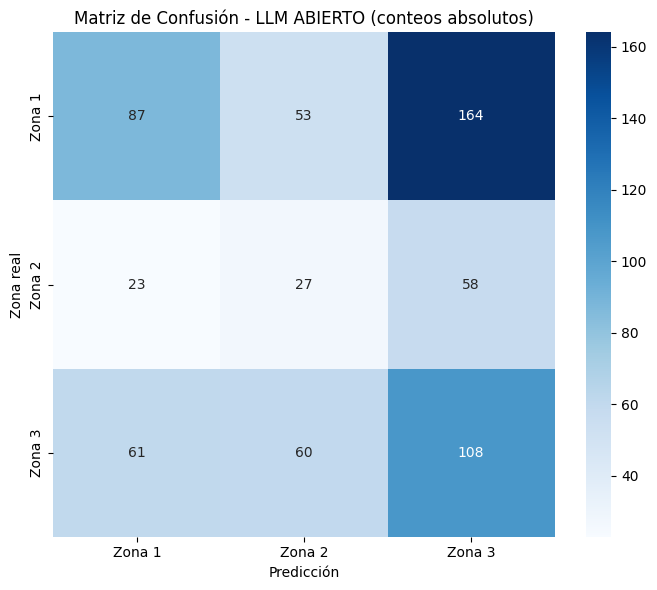

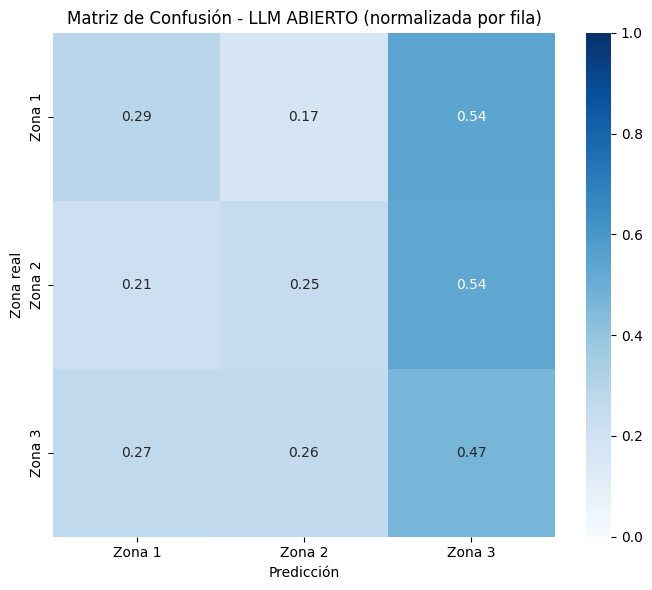

In [2]:
evaluador = EvaluadorResultados()
evaluador.evaluar("predicciones_finales_abierto.csv", "abierto")

Resultados prompt cerrado iteración 1


 EVALUACION MULTICLASE (ZONAS 1, 2 Y 3) 
Muestras evaluadas:           637
Accuracy:                     30.93%
Balanced accuracy:            31.38%
Precision macro:              30.56%
Recall macro:                 31.38%
F1 macro:                     29.38%
F1 weighted:                  30.91%
Predicciones no válidas:      4

Resumen detallado de las predicciones:
      vid_ID kicker_foot  zona_real prediccion_etiqueta  prediccion_numero  acierto
  v1_p1_diag     derecha          1             CENTRAL                  2    False
  v1_p2_diag     derecha          1             CRUZADO                  1     True
  v1_p3_diag     derecha          2             CENTRAL                  2     True
  v1_p4_diag     derecha          3             CRUZADO                  1    False
  v1_p5_diag     derecha          1             CRUZADO                  1     True
  v1_p6_diag     derecha          1             ABIERTO                  3    False
  v1_p7_diag     derecha          3       

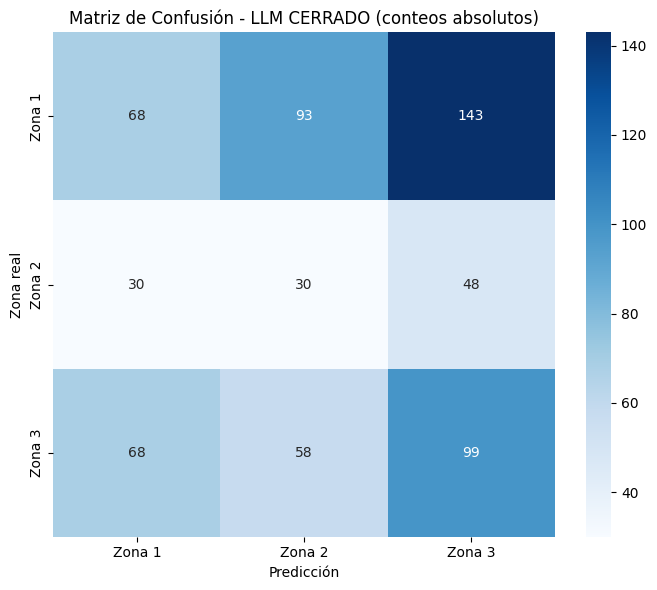

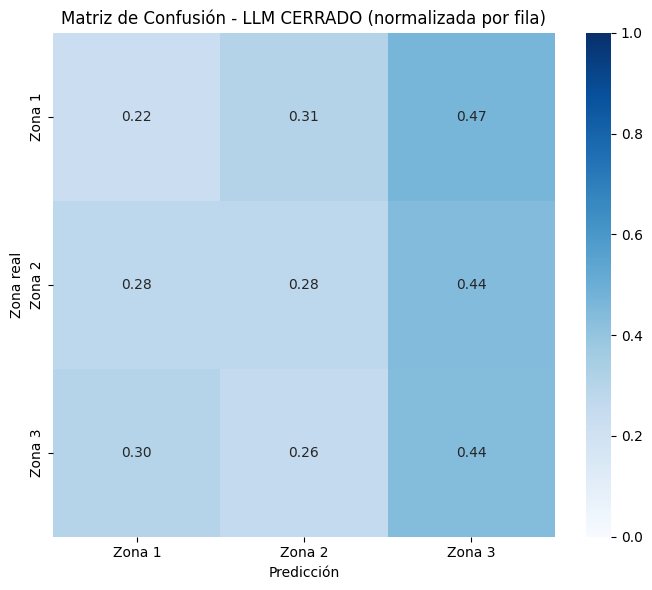

In [3]:
evaluador = EvaluadorResultados()
evaluador.evaluar("predicciones_finales_cerrado.csv", "cerrado")

### 9. Análisis Comparativo: Unificación Visual de Matrices de Confusión

Para presentar los resultados de la Iteración 1 de forma clara y rigurosa en la memoria del proyecto, se implementó un bloque de código final cuyo objetivo es generar una visualización comparativa unificada. En lugar de procesar y observar los experimentos de forma aislada, se diseñó un script que unifica las predicciones derivadas tanto de los *prompts* abiertos como de los cerrados para proyectarlas frente a frente en un único lienzo analítico.

Para asegurar la robustez en la carga y el cruce de los datos, el sistema no asume que los archivos de entrada sean correctos por defecto. Se aplica un control estricto de integridad estructural verificando las columnas y se examina la consistencia semántica detectando colisiones si un identificador de vídeo posee etiquetas contradictorias. A continuación, se realiza un cruce relacional del tipo *inner merge* entre la verdad base o *Ground Truth* y cada archivo de predicciones de forma independiente. Esto se hace para garantizar metodológicamente que el desempeño de ambos enfoques se evalúe exactamente sobre el mismo conjunto de vídeos válidos.

Para mantener la coherencia espacial durante la evaluación comparativa, se aplica nuevamente la regla de traducción de lateralidad, convirtiendo las etiquetas relativas generadas por el LLM en el sistema de coordenadas absolutas de la portería en función de la pierna hábil del jugador. Una vez extraídas las matrices de confusión absolutas mediante `scikit-learn`, se realiza un ajuste matemático crítico normalizando los valores por fila. Para lograr esto, se divide el contenido de cada celda entre la suma total de muestras de su respectiva zona real, de modo que la diagonal principal de la matriz pase a representar directamente la sensibilidad (*recall*) de cada clase en un rango de cero a uno. Este paso se aplica para permitir una comparación justa entre zonas que puedan tener un número desbalanceado de vídeos de prueba.

Para el renderizado dual y la exportación académica del gráfico, se utilizaron las capacidades combinadas de `matplotlib` y `seaborn`. Se instanció un lienzo de subgráficos compuesto por una fila y dos columnas, donde se proyectan los dos mapas de calor sincronizados, obligando a que la escala de color sea idéntica en ambos mediante los parámetros de valor mínimo y máximo. Finalmente, para asegurar una calidad óptima en el documento final, la imagen compuesta se exporta en alta resolución a 300 píxeles por pulgada con un ajuste paramétrico de los márgenes, generando un artefacto visual limpio y listo para su publicación.

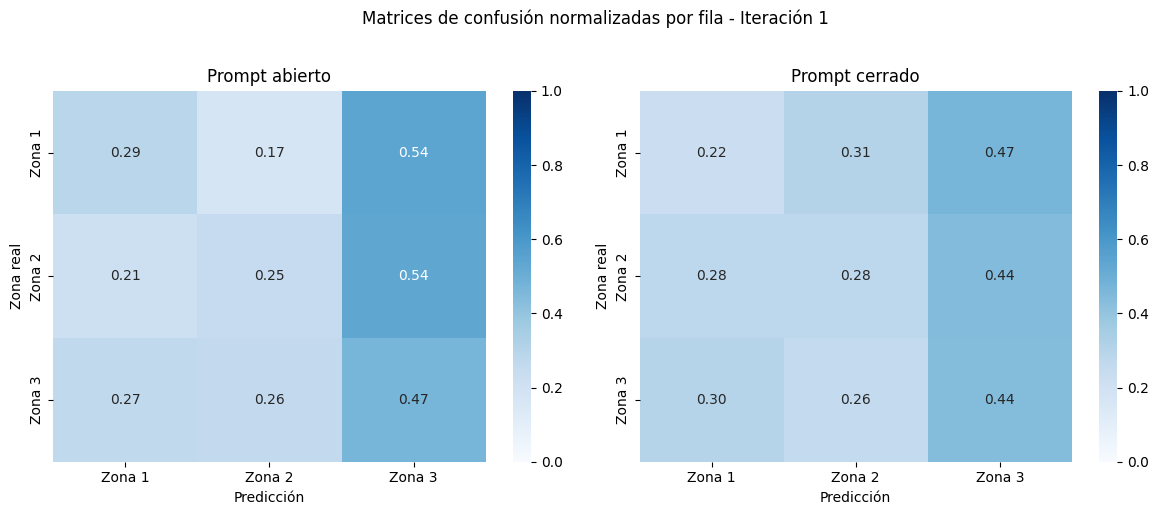

In [5]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

PRED_PATH_ABIERTO = "predicciones_finales_abierto.csv"
PRED_PATH_CERRADO = "predicciones_finales_cerrado.csv"
LABELS_PATH = "labeled_frames_grouped.csv"


def cargar_labels(labels_path):
    if not os.path.exists(labels_path):
        raise FileNotFoundError(f"No se ha encontrado '{labels_path}'")

    df_labels = pd.read_csv(labels_path)

    cols_labels_necesarias = {"vid_ID", "shoot_zone_grouped"}
    faltan_labels = cols_labels_necesarias - set(df_labels.columns)
    if faltan_labels:
        raise ValueError(f"Faltan columnas en labeled_frames_grouped.csv: {sorted(faltan_labels)}")

    df_labels = df_labels[["vid_ID", "shoot_zone_grouped"]].dropna().copy()
    df_labels["shoot_zone_grouped"] = df_labels["shoot_zone_grouped"].astype(int)

    inconsistencias = (
        df_labels.groupby("vid_ID")["shoot_zone_grouped"]
        .nunique()
        .reset_index(name="n_zonas_distintas")
    )
    inconsistencias = inconsistencias[inconsistencias["n_zonas_distintas"] > 1]

    if not inconsistencias.empty:
        ejemplos = inconsistencias["vid_ID"].astype(str).tolist()[:10]
        raise ValueError(
            "Hay videos con más de una zona real distinta en labeled_frames_grouped.csv. "
            f"Ejemplos: {ejemplos}"
        )

    df_labels = (
        df_labels.drop_duplicates(subset=["vid_ID"])
        .rename(columns={"shoot_zone_grouped": "zona_real"})
        .copy()
    )

    return df_labels


def mapear_a_numero(row):
    pred = str(row["prediccion_etiqueta"]).strip().upper()
    pierna = str(row["kicker_foot"]).strip().lower()

    if pred in ["CENTRAL", "CENTRO"]:
        return 2

    if pierna == "derecha":
        if pred == "CRUZADO":
            return 1
        if pred == "ABIERTO":
            return 3

    elif pierna == "izquierda":
        if pred == "CRUZADO":
            return 3
        if pred == "ABIERTO":
            return 1

    return -1


def preparar_df_pred(path_pred, df_labels):
    if not os.path.exists(path_pred):
        raise FileNotFoundError(f"No se ha encontrado '{path_pred}'")

    df_pred = pd.read_csv(path_pred)

    cols_pred_necesarias = {"vid_ID", "kicker_foot", "prediccion_etiqueta"}
    faltan_pred = cols_pred_necesarias - set(df_pred.columns)
    if faltan_pred:
        raise ValueError(f"Faltan columnas en {path_pred}: {sorted(faltan_pred)}")

    df = df_pred.merge(df_labels, on="vid_ID", how="inner")

    if df.empty:
        raise ValueError(f"El merge entre {path_pred} y las labels ha dado 0 filas.")

    df = df[df["zona_real"].isin([1, 2, 3])].copy()
    df["prediccion_numero"] = df.apply(mapear_a_numero, axis=1)
    df_validos = df[df["prediccion_numero"].isin([1, 2, 3])].copy()

    if df_validos.empty:
        raise ValueError(f"No hay predicciones válidas en {path_pred}")

    return df_validos


df_labels = cargar_labels(LABELS_PATH)
df_abierto = preparar_df_pred(PRED_PATH_ABIERTO, df_labels)
df_cerrado = preparar_df_pred(PRED_PATH_CERRADO, df_labels)

labels = [1, 2, 3]
nombres_clases = ["Zona 1", "Zona 2", "Zona 3"]

cm_abierto = confusion_matrix(df_abierto["zona_real"], df_abierto["prediccion_numero"], labels=labels)
cm_cerrado = confusion_matrix(df_cerrado["zona_real"], df_cerrado["prediccion_numero"], labels=labels)

cm_abierto_norm = cm_abierto.astype(float) / cm_abierto.sum(axis=1, keepdims=True)
cm_cerrado_norm = cm_cerrado.astype(float) / cm_cerrado.sum(axis=1, keepdims=True)

cm_abierto_norm = np.nan_to_num(cm_abierto_norm)
cm_cerrado_norm = np.nan_to_num(cm_cerrado_norm)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(
    cm_abierto_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=nombres_clases,
    yticklabels=nombres_clases,
    vmin=0,
    vmax=1,
    ax=axes[0]
)
axes[0].set_title("Prompt abierto")
axes[0].set_xlabel("Predicción")
axes[0].set_ylabel("Zona real")

sns.heatmap(
    cm_cerrado_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=nombres_clases,
    yticklabels=nombres_clases,
    vmin=0,
    vmax=1,
    ax=axes[1]
)
axes[1].set_title("Prompt cerrado")
axes[1].set_xlabel("Predicción")
axes[1].set_ylabel("Zona real")

plt.suptitle("Matrices de confusión normalizadas por fila - Iteración 1", y=1.02)
plt.tight_layout()
plt.savefig("matrices_confusion_iteracion1_comparativa.png", dpi=300, bbox_inches="tight")
plt.show()


### 10. Diagnóstico de Varianza: Análisis de Concentración de Etiquetas

Para servir como cierre analítico de esta primera iteración, se implementó este bloque de código destinado a auditar cualitativamente el comportamiento del modelo de visión (VLM) bajo la estricta restricción del *prompt* cerrado. Para mitigar el nuevo riesgo metodológico del sesgo hacia la respuesta segura, que surge precisamente al forzar a la red a usar etiquetas predefinidas, se automatizó este análisis de concentración. Se planteó este control predictivo porque si el VLM clasifica una variable cinemática (como la inclinación del tronco en el impacto) con la misma etiqueta en la inmensa mayoría de los vídeos debido a la oclusión o a la falta de resolución, esa característica pierde de inmediato todo su poder discriminativo para el modelo de lenguaje inferencial.

Para estructurar el texto generado y poder extraer conclusiones analíticas reales, se diseñaron las funciones `extraer_etiquetas_desde_memoria` y `expandir_etiquetas_cerradas`. Dado que las memorias visuales se encuentran almacenadas de forma predeterminada como bloques de texto multilínea, se utilizó manipulación de cadenas de texto (*string parsing*) para leer cada línea secuencialmente, ignorar los separadores de fase y dividir el contenido mediante el carácter de los dos puntos. Para adecuar esta información a un entorno de análisis numérico, se reconstruyeron los pares clave-valor, permitiendo así pivotar y ensanchar el *DataFrame* original para transformar un bloque de texto opaco en un conjunto de columnas tabulares donde cada variable biomecánica se evalúa de manera independiente.

Para cuantificar la varianza subyacente de las inferencias visuales, se implementó el método `porcentaje_categoria_dominante`. Por cada característica biomecánica previamente aislada, se calcula la moda estadística para aislar la etiqueta más repetida y se extrae su frecuencia relativa con respecto al volumen total de vídeos evaluados. Para diagnosticar visualmente la gravedad de este sesgo, se genera un resumen tabular en crudo y se proyecta un gráfico de barras horizontales a través de `matplotlib`, ordenando las variables de forma ascendente según su grado de concentración algorítmica.

Para comprender los límites del enfoque micro-biomecánico dentro del contexto general del proyecto, se analizan los resultados arrojados por esta gráfica comparativa. Se estableció que aquellas variables con una concentración cercana al cien por cien revelan empíricamente la incapacidad del modelo multimodal para percibir diferencias posicionales entre los distintos penaltis, anulando por completo el valor predictivo de dichas señales espaciales. Para fundamentar teóricamente el trabajo posterior, se utilizará este análisis crítico como puente directo y justificación técnica para el diseño de la segunda iteración metodológica, demostrando la necesidad de replantear qué tipo de información visual resulta verdaderamente útil y extraíble dada la limitación impuesta por la perspectiva de la cámara.

,variable,categoria_dominante,frecuencia_dominante,porcentaje_dominante
20,CIERRE_FINAL_GESTO,CERRADO,280,0.436817
3,PRE_ROTACION_TRONCO_PELVIS,NEUTRA,283,0.441498
7,POSICION_PIE_APOYO_BALON,ADELANTADO,289,0.450858
1,ENTRADA_LATERAL,DERECHA_VISUAL,360,0.561622
16,RELACION_APOYO_GOLPEO,CERRADA,370,0.577223
4,BASE_CARRERA,ABIERTA,378,0.589704
17,DIRECCION_SEGUIMIENTO,HACIA_DELANTE,384,0.599064
18,DIRECCION_RODILLA,HACIA_DENTRO,446,0.695788
21,ALTURA_PIE_FINAL,ALTA,450,0.702028
11,TRONCO_IMPACTO,HACIA_ATRAS_O_LATERAL,478,0.745710


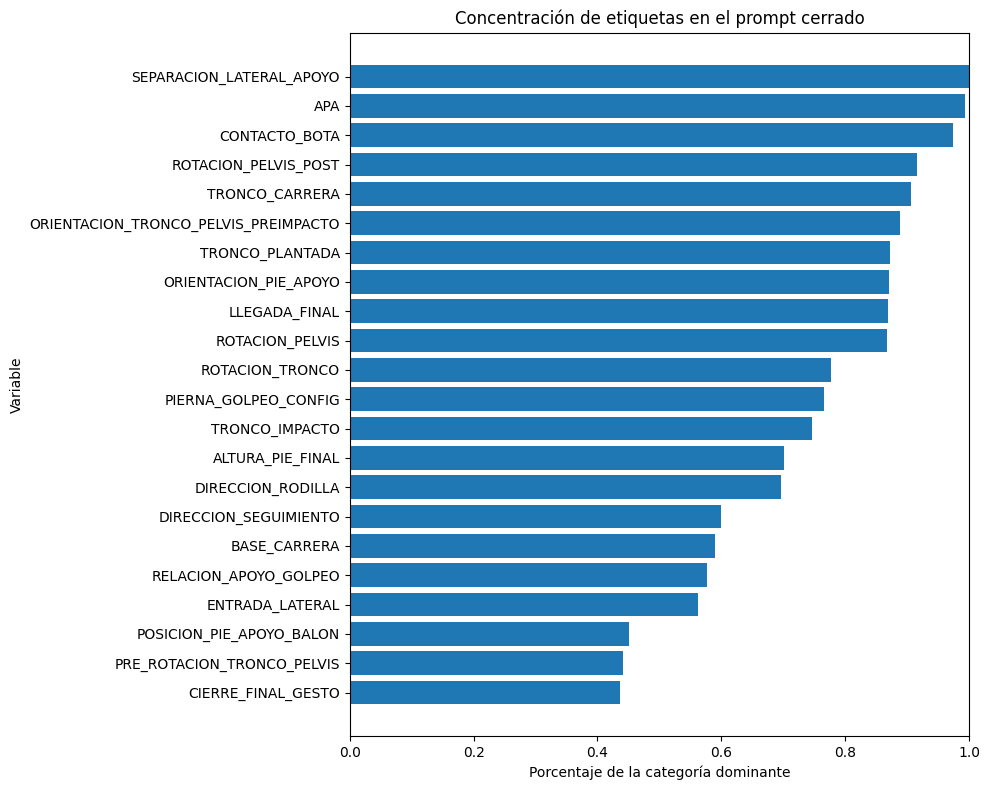

In [6]:
import os
import pandas as pd
import matplotlib.pyplot as plt

CSV_CERRADO = "memorias_visuales_cerrado.csv"


def cargar_csv_memorias_cerrado(path_csv):
    if not os.path.exists(path_csv):
        raise FileNotFoundError(f"No existe el archivo: {path_csv}")

    df = pd.read_csv(path_csv)

    columnas_obligatorias = ["vid_ID", "kicker_foot", "memoria_generada"]
    faltan = [c for c in columnas_obligatorias if c not in df.columns]
    if faltan:
        raise ValueError(f"En {path_csv} faltan columnas obligatorias: {faltan}")

    return df.copy()


def extraer_etiquetas_desde_memoria(memoria):
    resultado = {}

    if not isinstance(memoria, str):
        return resultado

    for linea in memoria.splitlines():
        linea = linea.strip()

        if not linea:
            continue

        if linea.startswith("---") and linea.endswith("---"):
            continue

        if ":" in linea:
            clave, valor = linea.split(":", 1)
            clave = clave.strip()
            valor = valor.strip()

            if clave and valor:
                resultado[clave] = valor

    return resultado


def expandir_etiquetas_cerradas(df_cerrado):
    filas = []

    for _, row in df_cerrado.iterrows():
        base = {
            "vid_ID": row["vid_ID"],
            "kicker_foot": row["kicker_foot"],
        }

        etiquetas = extraer_etiquetas_desde_memoria(row["memoria_generada"])
        fila = {**base, **etiquetas}
        filas.append(fila)

    if not filas:
        return pd.DataFrame()

    return pd.DataFrame(filas)


def porcentaje_categoria_dominante(serie):
    serie = serie.dropna().astype(str).str.strip()
    if len(serie) == 0:
        return 0.0, "NA", 0

    conteo_abs = serie.value_counts(dropna=False)
    conteo_rel = serie.value_counts(normalize=True, dropna=False)

    categoria = conteo_rel.index[0]
    porcentaje = conteo_rel.iloc[0]
    frecuencia = conteo_abs.iloc[0]

    return porcentaje, categoria, frecuencia


def resumen_concentracion_cerrado(df_expandido):
    columnas_meta = {"vid_ID", "kicker_foot"}
    variables = [c for c in df_expandido.columns if c not in columnas_meta]

    filas = []
    for var in variables:
        pct, cat, freq = porcentaje_categoria_dominante(df_expandido[var])
        filas.append({
            "variable": var,
            "categoria_dominante": cat,
            "frecuencia_dominante": freq,
            "porcentaje_dominante": pct,
        })

    if not filas:
        return pd.DataFrame()

    return pd.DataFrame(filas).sort_values("porcentaje_dominante", ascending=True)


df_cerrado = cargar_csv_memorias_cerrado(CSV_CERRADO)
df_expandido = expandir_etiquetas_cerradas(df_cerrado)
tabla_concentracion = resumen_concentracion_cerrado(df_expandido)

display(tabla_concentracion)

plt.figure(figsize=(10, 8))
plt.barh(tabla_concentracion["variable"], tabla_concentracion["porcentaje_dominante"])
plt.xlabel("Porcentaje de la categoría dominante")
plt.ylabel("Variable")
plt.title("Concentración de etiquetas en el prompt cerrado")
plt.xlim(0, 1)
plt.tight_layout()
plt.savefig("concentracion_etiquetas_cerrado_iteracion1.png", dpi=300, bbox_inches="tight")
plt.show()

# Iteración 2: Pivotaje hacia Señales Macro-Gestuales y Reformulación de la Memoria Visual

Las conclusiones extraídas del diagnóstico de la primera iteración obligaron a un replanteamiento crítico sobre la naturaleza de la información que se exigía al modelo de visión. Quedó demostrado empíricamente que los indicadores micro-biomecánicos más finos —como la rotación exacta del tobillo de apoyo, el milímetro preciso de contacto en la bota o los grados de flexión articular— no podían ser inferidos con fiabilidad dadas las severas limitaciones intrínsecas del *dataset* (desenfoque por movimiento, oclusiones, resolución y perspectiva diagonal de la cámara). Seguir insistiendo en la extracción de esta micro-cinemática no solo aumentaba el riesgo de alucinación por parte del VLM, sino que saturaba de ruido el proceso de razonamiento posterior. 

En respuesta a este diagnóstico, la segunda iteración ejecuta un pivotaje metodológico radical: abandona la granularidad anatómica y transita hacia un enfoque **macro-gestual**. La estrategia ahora consiste en orientar la atención de la red neuronal hacia configuraciones corporales de mayor escala, es decir, patrones de movimiento globales y robustos que sobrevivan a la distorsión visual. En esta fase, el análisis prioriza la inclinación general del torso, la orientación proyectada del pecho, la inercia visible de la cadera y la trayectoria residual del cuerpo durante la fase de seguimiento (post-impacto). 

La arquitectura modular del sistema se mantiene constante. **Qwen2.5-VL-7B** sigue actuando como el motor encargado de generar la memoria visual temporal (dividiendo el vídeo en carrera, planta, impacto y seguimiento), mientras que un Modelo de Lenguaje asume la tarea de leer dicha memoria e inferir la lateralidad del disparo en coordenadas relativas al jugador (`CRUZADO`, `CENTRAL` o `ABIERTO`). Lo que cambia profundamente es el contrato semántico establecido en el *prompt* de extracción.

Para poner a prueba este nuevo paradigma, el cuaderno explora tres configuraciones distintas de memoria visual:
* **Primera variante abierta:** Mantiene un formato narrativo libre, pero prohíbe explícitamente al VLM centrarse en microdetalles. Exige descripciones sobre la dinámica global de aproximación, la postura general del torso en el apoyo, la posición del brazo de equilibrio y el frenado o cruce de piernas en la inercia final.
* **Segunda variante abierta:** Refina la variante anterior anclando la narrativa a señales visuales aún más concretas y menos abstractas. Instruye al VLM para que describa las trayectorias en relación directa con el encuadre (por ejemplo, especificando hacia qué lado exacto de la imagen se desplaza la pierna tras el impacto, o si el pie supera o no la línea visual de la cadera).
* **Variante cerrada:** Abandona el texto libre en favor de una matriz de etiquetas discretas y sintéticas de alto nivel (tipo de carrera, dirección predominante del pecho, superficie general de impacto). Esta formulación opera bajo la hipótesis de que forzar un catálogo cerrado y grueso mitigará la dispersión lingüística y estabilizará el razonamiento posterior.

Acorde con estas modificaciones estructurales, se ajusta el determinismo de la generación. Las variables abiertas se ejecutan con una ligera libertad léxica (Temperatura = 0.3), mientras que la variante cerrada y, crucialmente, la fase de inferencia final del LLM, se ejecutan con determinismo absoluto (Temperatura = 0.0) para garantizar que la varianza predictiva proceda exclusivamente de la observación visual y no de alucinaciones sintácticas. En esencia, la Iteración 2 actúa como el primer gran esfuerzo por adaptar las expectativas algorítmicas a la realidad física de los datos televisivos.

### 1. Configuración Base y Procesamiento Visual

Para inicializar el entorno de trabajo y el motor de procesamiento visual de esta segunda iteración, se reutilizó íntegramente el bloque de código fundacional detallado al inicio de la iteración previa, manteniendo inalteradas las rutinas encargadas de la extracción, reescalado y sincronización temporal de los fotogramas.

In [ ]:
import cv2
import base64
import os
import time
import pandas as pd
from openai import OpenAI
import matplotlib.pyplot as plt
import numpy as np

CLIENT = OpenAI(base_url="http://localhost:1234/v1", api_key="lm-studio")

BASE_DIR = r'C:\Users\david\OneDrive\Desktop\TFT_LLMPenalties2026'
CSV_ORIGINAL_PATH = os.path.join(BASE_DIR, 'labeled_frames_cuttedvids.csv')
CSV_GROUPED_PATH = os.path.join(BASE_DIR, 'labeled_frames_grouped.csv')
VIDEOS_DIR = os.path.join(BASE_DIR, 'modified_videos')
RESULTADOS_MEMORIA_PATH = os.path.join(BASE_DIR, 'memorias_visuales.csv')
DF_ORIGINAL = pd.read_csv(CSV_ORIGINAL_PATH)

def resize_keep_aspect_ratio(image, target_size=384):
    """ Escala una imagen sin deformarla y añade franjas negras """
    old_h, old_w = image.shape[:2]
    ratio = min(target_size / old_w, target_size / old_h)
    new_w = int(old_w * ratio)
    new_h = int(old_h * ratio)
    
    if ratio < 1.0:
        interp = cv2.INTER_AREA
    else:
        interp = cv2.INTER_CUBIC
        
    resized = cv2.resize(image, (new_w, new_h), interpolation=interp)
    
    delta_w = target_size - new_w
    delta_h = target_size - new_h
    top, bottom = delta_h // 2, delta_h - (delta_h // 2)
    left, right = delta_w // 2, delta_w - (delta_w // 2)
    
    padded_img = cv2.copyMakeBorder(resized, top, bottom, left, right, 
                                    cv2.BORDER_CONSTANT, value=[0, 0, 0])
    return padded_img

def encode_image_to_base64(frame):
    _, buffer = cv2.imencode('.jpg', frame, [int(cv2.IMWRITE_JPEG_QUALITY), 95])
    return base64.b64encode(buffer).decode('utf-8')

def get_correct_bbox(vid_data, frame_idx_modificado, target_frames=64):
    total_original_frames = len(vid_data)
    if total_original_frames == 0: return None
    if total_original_frames > target_frames:
        indice_real = frame_idx_modificado + (total_original_frames - target_frames)
    elif total_original_frames < target_frames:
        padding_size = target_frames - total_original_frames
        indice_real = 0 if frame_idx_modificado < padding_size else frame_idx_modificado - padding_size
    else:
        indice_real = frame_idx_modificado
    indice_real = min(indice_real, len(vid_data) - 1)
    return int(vid_data.iloc[indice_real]['BB_x']), int(vid_data.iloc[indice_real]['BB_y']), int(vid_data.iloc[indice_real]['BB_w']), int(vid_data.iloc[indice_real]['BB_h'])

def get_kick_frame_idx(vid_data, target_frames=64):
    total_orig = len(vid_data)
    kick_rows = vid_data[vid_data['kick_frame'] == 1]
    kick_orig = int(kick_rows.iloc[0]['frame_id']) if len(kick_rows) > 0 else total_orig // 2

    if total_orig > target_frames:
        kick_mod = kick_orig - (total_orig - target_frames)
    elif total_orig < target_frames:
        kick_mod = kick_orig + (target_frames - total_orig)
    else:
        kick_mod = kick_orig

    total_mod = min(total_orig, target_frames)
    return max(0, min(total_mod - 1, kick_mod))

def crop_frame(frame, vid_data, frame_idx, target_frames=64, pad=100):
    """ Recorta el jugador usando el Bounding Box y añade un margen de padding dinámico """
    bbox = get_correct_bbox(vid_data, frame_idx, target_frames=target_frames)
    if bbox:
        x, y, w, h = bbox
        H, W, _ = frame.shape
        x1, y1 = max(0, x - pad), max(0, y - pad)
        x2, y2 = min(W, x + w + pad), min(H, y + h + pad)
        return resize_keep_aspect_ratio(frame[y1:y2, x1:x2], target_size=384)
    return resize_keep_aspect_ratio(frame, target_size=512)

def sample_frames_from_range(frames, vid_data, start, end, n_samples):
    segment = list(range(start, end))
    if not segment: return []
    if len(segment) <= n_samples:
        indices = segment
    else:
        indices = [segment[int(i * len(segment) / n_samples)] for i in range(n_samples)]
    return [encode_image_to_base64(crop_frame(frames[i], vid_data, i)) for i in indices]

def extract_frames_by_phase(video_path, vid_data, n_carrera_1=4, n_carrera_2=6, n_impacto=3, n_seguimiento=6):
    cap = cv2.VideoCapture(video_path)
    frames = []
    while True:
        ret, frame = cap.read()
        if not ret: break
        frames.append(frame)
    cap.release()
    if not frames: return None

    kick_idx = get_kick_frame_idx(vid_data)
    total = len(frames)
    
    fase_carrera_1   = (0, max(1, kick_idx - 12))
    
    fase_carrera_2   = (max(1, kick_idx - 12), max(2, kick_idx - 1))
    
    fase_impacto     = (max(0, kick_idx - 1), min(total, kick_idx + 2))
    
    fase_seguimiento = (min(total, kick_idx + 2), total)

    return {
        "carrera_1":     sample_frames_from_range(frames, vid_data, *fase_carrera_1,   n_carrera_1),
        "carrera_2":     sample_frames_from_range(frames, vid_data, *fase_carrera_2,   n_carrera_2),
        "impacto":       sample_frames_from_range(frames, vid_data, *fase_impacto,     n_impacto),
        "seguimiento":   sample_frames_from_range(frames, vid_data, *fase_seguimiento, n_seguimiento),
        "kick_idx":      kick_idx,
        "total":         total,
        "n_carrera_1":   n_carrera_1,
        "n_carrera_2":   n_carrera_2,
        "n_impacto":     n_impacto,
        "n_seguimiento": n_seguimiento,
    }

### 2. Generación de la Memoria Visual: Enfoque Macro-Gestual (Prompt Cerrado)

Para materializar la variante cerrada de esta segunda iteración, se implementó un bloque de código que hereda íntegramente la arquitectura de extracción y comunicación de la fase anterior. Al igual que en los experimentos previos, se utilizó el modelo multimodal Qwen2.5-VL-7B para procesar secuencialmente los fotogramas codificados en base64, manteniendo inalterada la división cronológica del movimiento en cuatro fases temporales. Sin embargo, el contenido lógico de las peticiones enviadas a la red neuronal experimentó una transformación profunda.

Para adaptar el sistema al nuevo enfoque macro-gestual y reducir las alucinaciones derivadas de las limitaciones del vídeo original, se rediseñó por completo el *prompt* del sistema introduciendo restricciones físicas explícitas. En lugar de confiar ciegamente en la interpretación libre del modelo, se inyectaron reglas biomecánicas de obligado cumplimiento. Por ejemplo, se le advierte de la imposibilidad anatómica de que la rodilla apunte hacia arriba en el instante del golpeo, o la obligatoriedad física de que la inercia de la pierna siga una trayectoria ascendente tras el impacto. Para mitigar los errores de interpretación espacial, se informó explícitamente a la red neuronal de la ubicación diagonal de la cámara y se establecieron pautas de tolerancia al desenfoque (*motion blur*), instruyendo al modelo a deducir posiciones basándose en la cadena cinética general del cuerpo en lugar de intentar enfocar detalles borrosos.

Para extraer una representación verdaderamente sintética y global de la acción, se configuraron peticiones de usuario estrictamente cerradas que exigen la selección de una única etiqueta predefinida para cada variable de alto nivel. En la fase de carrera inicial, se evalúa exclusivamente el ángulo macroscópico de aproximación; en la plantada, se consulta la orientación general del pecho y la punta del pie de apoyo; durante el impacto crítico, se restringe la observación a la dirección de la rodilla y la superficie aparente de la bota; y en la secuencia de seguimiento, se prioriza la trayectoria de la pierna y la inercia de compensación de los hombros. Para estabilizar al máximo la selección de estos parámetros discretos por parte del VLM y minimizar la variabilidad inherente a la generación de texto, se ajustó la temperatura operativa del modelo a un valor mucho más restrictivo (`temperature=0.1`).

Para ensamblar una memoria visual altamente comprimida y estructurada de cara a la evaluación final, se rediseñó la función `construir_memoria_estructurada` integrando el uso de expresiones regulares. Como el *prompt* obliga al modelo de visión a redactar primero una breve justificación anatómica antes de imprimir su conclusión final entre corchetes, el código utiliza la librería `re` de Python para rastrear dinámicamente estas etiquetas (por ejemplo, `[ANGULO]` o `[RODILLA]`) y aislar únicamente la respuesta discreta. Esto se implementó para filtrar todo el ruido narrativo y generar un texto concatenado extremadamente limpio y estandarizado, asegurando que el modelo de lenguaje de la siguiente etapa reciba un bloque de información categórica sin ambigüedades.

In [2]:
import re

def construir_memoria_estructurada(desc_carrera_1, desc_carrera_2, desc_impacto, desc_seguimiento):
    def extraer(texto, etiqueta_regex):
        if not texto: return "no se apreció"
        match = re.search(rf"\[?{etiqueta_regex}\]?.*?:?\s*(.*)", texto, re.IGNORECASE)
        if match:
            return match.group(1).replace('*', '').strip().split('\n')[0]
        return "no se apreció"

    aproximacion = extraer(desc_carrera_1, "ANGULO") 
    apoyo        = extraer(desc_carrera_2, "PIE_APOYO")
    pecho        = extraer(desc_carrera_2, "PECHO")
    rodilla      = extraer(desc_impacto,   "RODILLA")
    pie_impacto  = extraer(desc_impacto,   "PIE_IMPACTO")
    trayectoria  = extraer(desc_seguimiento, "TRAYECTORIA") 
    inercia      = extraer(desc_seguimiento, "INERCIA")

    return (
        f"CARRERA: {aproximacion}\n"
        f"APOYO: Pie apunta a {apoyo} / Pecho mira a {pecho}\n"
        f"IMPACTO: Rodilla apunta a {rodilla} / Superficie visible: {pie_impacto}\n"
        f"SEGUIMIENTO: {trayectoria} / Inercia tronco: {inercia}"
    )

def generar_memoria_visual(video_path, vid_data, pierna):
    fases = extract_frames_by_phase(video_path, vid_data) 
    if not fases: return None

    def llamar_vlm(frames_b64, prompt_sistema, prompt_usuario):
        if not frames_b64: return "No hay frames."
        content = [{"type": "text", "text": prompt_usuario}]
        for img in frames_b64:
            content.append({"type": "image_url", "image_url": {"url": f"data:image/jpeg;base64,{img}"}})
        try:
            response = CLIENT.chat.completions.create(
                model="local-model", 
                messages=[
                    {"role": "system", "content": prompt_sistema},
                    {"role": "user",   "content": content}
                ],
                max_tokens=400,
                temperature=0.1 
            )
            return response.choices[0].message.content
        except Exception as e:
            return f"Error: {e}"

    prompt_sistema_fase = f"""Eres un analista biomecánico de visión artificial experto en fútbol.
DATO FIJO: El jugador patea con la pierna {pierna.upper()}.
CÁMARA: Situada en DIAGONAL y a la DERECHA del jugador.

REGLAS BIOMECÁNICAS ESTRICTAS (OBLIGATORIAS):
1. ANATOMÍA DEL IMPACTO: En el momento del golpeo, la rodilla de la pierna activa apunta hacia adelante o hacia abajo, NUNCA hacia arriba.
2. FÍSICA DEL SEGUIMIENTO: Tras el impacto, la pierna de golpeo SIEMPRE sigue una trayectoria ascendente (hacia arriba) por inercia, NUNCA descendente. El torso gira en sentido contrario a la pierna para compensar.
3. TOLERANCIA AL DESENFOQUE: Las extremidades en movimiento tendrán 'motion blur'. Infiere la posición usando la cadena cinética (cadera, torso, postura general). Usa 'BORROSO' SOLO si la imagen está totalmente obstruida.

ESTRUCTURA OBLIGATORIA:
ANÁLISIS VISUAL: (Razonamiento de 1-2 líneas justificando la postura anatómica)
[ETIQUETA]: (Conclusión estricta de máximo 5 palabras)"""

    desc_carrera_1 = llamar_vlm(
        fases["carrera_1"], prompt_sistema_fase,
        f"""FASE DE CARRERA INICIAL. 
Evalúa el ángulo de aproximación del jugador hacia el balón.
Elige UNA de estas opciones para la etiqueta: [Frontal, Diagonal, Lateral].
Responde estrictamente:
[ANGULO]: (Tu elección)"""
    )

    desc_carrera_2 = llamar_vlm(
        fases["carrera_2"], prompt_sistema_fase,
        f"""FASE DE CARRERA FINAL (Plantada).
Evalúa hacia dónde apunta la PUNTA del pie de apoyo.
Elige UNA opción:
Pie: [Apunta recto al frente, Apunta hacia afuera (abierto), Apunta hacia adentro (cerrado)]
Pecho: [Frontal al balón, Ladeado]
Responde estrictamente:
[PIE_APOYO]: (Tu elección)
[PECHO]: (Tu elección)"""
    )

    desc_impacto = llamar_vlm(
        fases["impacto"], prompt_sistema_fase,
        f"""FASE DE IMPACTO. Pierna: {pierna.upper()}.
Recuerda la Regla 1: La rodilla no puede apuntar arriba.
Elige UNA opción para cada etiqueta:
Rodilla: [Adelante, Abajo/Balón]
Superficie: [Empeine total, Empeine interior, Interior, Puntera]
Responde estrictamente:
[RODILLA]: (Tu elección)
[PIE_IMPACTO]: (Tu elección)"""
    )

    desc_seguimiento = llamar_vlm(
    fases["seguimiento"], prompt_sistema_fase,
    f"""FASE DE SEGUIMIENTO. Pierna que patea: {pierna.upper()}.
OJO: La cámara está en DIAGONAL. No confundas la perspectiva con el giro real del jugador.
Fíjate EXCLUSIVAMENTE en los HOMBROS y la CADERA tras el impacto.
Elige UNA opción estricta para cada etiqueta:
Trayectoria pierna: [Cruza el eje del cuerpo, Sigue recta hacia adelante, Se abre hacia la derecha]
Inercia tronco: [Hombros giran bruscamente a la izquierda, Hombros se quedan mirando al frente, Hombros caen hacia atrás/derecha]
Responde estrictamente:
[TRAYECTORIA]: (Tu elección)
[INERCIA]: (Tu elección)"""
)

    return {
        "final": construir_memoria_estructurada(desc_carrera_1, desc_carrera_2, desc_impacto, desc_seguimiento),
        "raw_1": desc_carrera_1,
        "raw_2": desc_carrera_2,
        "raw_3": desc_impacto,
        "raw_4": desc_seguimiento
    }

### 3. Generación de la Memoria Visual: Enfoque Macro-Gestual (Primera Variante Abierta)

Para materializar la primera variante abierta de esta segunda iteración, se implementó un bloque de código que utiliza nuevamente el modelo multimodal Qwen2.5-VL-7B. Dado que la estructura algorítmica de extracción de fotogramas, codificación en base64 y concatenación temporal de las fases mediante la función `construir_memoria_estructurada` es idéntica a la detallada en la iteración anterior, la arquitectura base se mantuvo inalterada. Sin embargo, para adaptar el sistema al nuevo paradigma macro-gestual, se rediseñó por completo el contenido semántico de las peticiones textuales con el objetivo de alejar al modelo de los microdetalles y orientarlo hacia configuraciones corporales globales mucho más visibles.

Para forzar al modelo de visión a comprometerse con una interpretación y evitar las respuestas evasivas derivadas de la perspectiva o el desenfoque del vídeo, se introdujo una regla absoluta en el *prompt* del sistema. Se prohibió explícitamente a la red neuronal utilizar frases como "no es visible" o "no se puede determinar", obligándola a estimar la postura basándose en los píxeles disponibles. Además, para evitar que el modelo contaminara la memoria visual con conocimientos adquiridos durante su entrenamiento predeterminado, se le vetó el uso de biomecánica teórica, exigiéndole que describiera exclusivamente lo que captaba en la imagen sin asumir posturas típicas o estandarizadas.

Para capturar la dinámica global del movimiento durante las secuencias previas al contacto, se modificaron los *prompts* de la carrera y la plantada enfocándolos en patrones biomecánicos de gran escala. En la fase de carrera inicial, se le pide a la red que evalúe la amplitud de la zancada, el balanceo de los brazos para generar momento angular y la fluctuación del centro de gravedad. Al llegar a la fase de apoyo, la atención se desvía del análisis milimétrico para solicitar una lectura general sobre la inclinación del torso respecto al eje del balón y la orientación macroscópica del pie de planta, buscando determinar si este adopta una dirección frontal natural o si apunta claramente hacia el exterior.

Para extraer características espacialmente robustas durante el instante crítico del golpeo y su inercia posterior, los *prompts* de impacto y seguimiento se reorientaron hacia el análisis de grandes segmentos articulares. En el fotograma del contacto, se instruye al modelo para que ignore la zona de la bota y centre su atención visual en la extensión del brazo de equilibrio y en la apertura general de la cadera de la pierna activa. Posteriormente, en la fase de seguimiento, se evalúa macroscópicamente si la rodilla apunta hacia el frente o hacia el lateral, y se examina si la extremidad frena en seco su recorrido o si genera un latigazo cruzando el eje del cuerpo. Para permitir esta fluidez descriptiva manteniendo la coherencia narrativa del texto devuelto, se configuró la inferencia del servidor con una temperatura operativa ligeramente superior (`temperature=0.3`).

In [2]:
import pandas as pd

def construir_memoria_estructurada(desc_carrera_1, desc_carrera_2, desc_impacto, desc_seguimiento):
    def limpiar(texto):
        return texto.strip() if texto else "No se pudo extraer información."

    return (
        f"--- FASE DE CARRERA INICIAL ---\n{limpiar(desc_carrera_1)}\n\n"
        f"--- FASE DE PLANTA/APOYO ---\n{limpiar(desc_carrera_2)}\n\n"
        f"--- FASE DE IMPACTO ---\n{limpiar(desc_impacto)}\n\n"
        f"--- FASE DE SEGUIMIENTO E INERCIA ---\n{limpiar(desc_seguimiento)}"
    )

def generar_memoria_visual(video_path, vid_data, pierna):
    fases = extract_frames_by_phase(video_path, vid_data) 
    if not fases: return None

    def llamar_vlm(frames_b64, prompt_sistema, prompt_usuario):
        if not frames_b64: return "No hay frames."
        content = [{"type": "text", "text": prompt_usuario}]
        for img in frames_b64:
            content.append({"type": "image_url", "image_url": {"url": f"data:image/jpeg;base64,{img}"}})
        try:
            response = CLIENT.chat.completions.create(
                model="local-model", 
                messages=[{"role": "system", "content": prompt_sistema},
                          {"role": "user",   "content": content}],
                max_tokens=800,
                temperature=0.3 
            )
            return response.choices[0].message.content
        except Exception as e:
            return f"Error visual: {e}"

    prompt_sistema_fase = f"""Eres un analista biomecánico de visión artificial.
Analizas a un jugador pateando un penalti con la pierna {pierna.upper()}, 
visto desde una cámara diagonal trasera.

REGLA ABSOLUTA: SIEMPRE debes describir lo que ves. 
Nunca respondas "no es visible" ni "no se puede determinar".
Si hay incertidumbre, describe lo que más probablemente ves y añade "(estimación)".
Las imágenes siempre contienen información útil. Úsala.
PROHIBIDO usar biomecánica teórica para deducir respuestas.
Cada afirmación debe basarse en píxeles concretos que puedas señalar.
Si usas la palabra 'típico' o 'consistente con', te estás equivocando. Describe SOLO lo que ves, no lo que sabes."""


    desc_carrera_1 = llamar_vlm(
        fases["carrera_1"], prompt_sistema_fase,
        f"""Compara el inicio y el final de esta secuencia de aproximación al balón y describe los siguientes aspectos:
        
1. Ángulo de Aproximación (APA): Identifica en qué lado del balón inicia la carrera el jugador (izquierda o derecha visualmente). A partir de ahí, describe la trayectoria espacial de su centro de masa para llegar al balón. ¿Es una aproximación frontal, o una diagonal cruzada hacia la derecha/izquierda?
2. Patrón de Marcha y Postura: Describe la inclinación del torso respecto a la cadera durante la carrera. ¿El jugador mantiene una postura erguida o su centro de gravedad desciende a medida que se acerca al balón?
3. Dinámica del movimiento: Describe la amplitud de la zancada y cómo el jugador balancea los brazos para generar momento angular."""
    )

    pie_apoyo = "izquierdo" if pierna.lower() == "derecha" else "derecho"

    desc_carrera_2 = llamar_vlm(
        fases["carrera_2"], prompt_sistema_fase,
        f"""Observa la secuencia de la fase de planta y describe en texto libre:

1. Ángulo de llegada: Confirma desde qué dirección (izquierda o derecha del balón) se ha aproximado el jugador para realizar la plantada.

2. Postura del torso: Describe la inclinación del torso. ¿El jugador mantiene el tronco erguido o se inclina hacia adelante, adelantando los hombros sobre el eje del balón?

3. Orientación del pie de apoyo ({pie_apoyo.upper()}): Teniendo en cuenta que la cámara graba desde una diagonal trasera, evalúa la dirección biomecánica real del pie en el campo. ¿La punta está orientada hacia la zona de la portería (al frente/ligeramente cruzado) o apunta de forma antinatural hacia el exterior? 

4. Ubicación respecto al balón: En el eje de avance, ¿el pie de apoyo se planta retrasado, alineado a la misma altura, o adelantado respecto a la línea imaginaria que cruza el centro del balón?"""
    )

    brazo_equilibrio = "izquierdo" if pierna.lower() == "derecha" else "derecho"
    
    desc_impacto = llamar_vlm(
    fases["impacto"], prompt_sistema_fase,
    f"""Observa el frame exacto del contacto pie-balón y responde SOLO a esto:

1. El Brazo de Equilibrio (CRÍTICO): Fíjate en el brazo {brazo_equilibrio.upper()} del jugador. ¿Está recogido/flexionado cerca del cuerpo, o está completamente extendido y levantado hacia afuera (como un ala) alejándose del torso?

2. Inclinación de la Espalda: ¿La espalda está curvada hacia adelante (encorvada sobre el balón) o el jugador echa el tronco ligeramente hacia atrás/hacia el lado de apoyo?

3. Orientación de la Cadera: Ignora la bota. Fíjate en la cadera de la pierna de golpeo ({pierna.upper()}). ¿Está rotada agresivamente hacia adelante buscando la portería, o se nota que la cadera se ha "abierto" hacia el exterior?"""
)

    desc_seguimiento = llamar_vlm(
        fases["seguimiento"], prompt_sistema_fase,
        f"""Mira SOLO la fase de seguimiento (después del impacto).

1. La Rodilla de Golpeo (CRÍTICO): Fíjate en la rodilla de la pierna {pierna.upper()}. Tras golpear, ¿la rodilla apunta hacia el frente (o hacia adentro, cruzando el cuerpo), o la rodilla se queda apuntando hacia AFUERA (hacia el lateral del campo) revelando que la cadera se quedó abierta?

2. Frenado vs Cruce: ¿La pierna de golpeo frena su recorrido rápidamente tras el impacto, o da un latigazo cruzando violentamente por delante de la pierna de apoyo?

3. Altura del pie: ¿El pie de golpeo sube por encima de la cadera o se queda cerca del césped?"""
    )

    return {
        "final": construir_memoria_estructurada(desc_carrera_1, desc_carrera_2, desc_impacto, desc_seguimiento)
    }

### 4. Generación de la Memoria Visual: Enfoque Macro-Gestual (Segunda Variante Abierta)

Para materializar la segunda variante abierta de esta iteración metodológica, se mantuvo intacta la arquitectura de extracción visual y el *prompt* de sistema utilizados en la primera variante, operando nuevamente sobre el modelo Qwen2.5-VL-7B. Dado que la evaluación de la carrera inicial y la fase de plantada demostraron ser robustas bajo los criterios macro-gestuales previamente definidos, se conservaron sus respectivas instrucciones inalteradas. La diferencia metodológica de este bloque de código radica exclusivamente en la profunda reestructuración de los *prompts* correspondientes a las fases de impacto y seguimiento, con el objetivo de anclar el análisis en señales visuales todavía más literales y reducir el margen para descripciones abstractas.

Para reorientar la atención del modelo durante el fotograma exacto del contacto pie-balón, se sustituyó la observación previa del brazo de equilibrio y la apertura de cadera por un análisis más directo de la orientación del torso y el estado articular. A través del nuevo *prompt* de impacto, se instruye a la red neuronal para que evalúe hacia dónde apunta el pecho del lanzador, determinando si el cuerpo se encuentra en pleno giro dinámico intentando cuadrarse hacia la portería o si ya ha rotado hacia algún lateral. Adicionalmente, se solicita una estimación de la zona visible de contacto de la bota asumiendo las limitaciones de resolución de la cámara, y se exige describir el grado de flexión tanto de la pierna de apoyo como de la extremidad de golpeo, reconociendo la ligera flexión biomecánica natural que se produce para no bloquear la articulación durante el impacto.

Para eliminar cualquier rastro de ambigüedad semántica en la interpretación de la inercia del movimiento, se reformuló radicalmente la petición de la fase de seguimiento, obligando al modelo de visión a justificar sus afirmaciones basándose estrictamente en el desplazamiento espacial dentro del encuadre. En lugar de preguntar por conceptos biomecánicos relativos o interpretativos, se le exige que determine de forma binaria y literal si el pie de la pierna activa se mueve hacia la derecha o hacia la izquierda de la imagen tras el golpeo, justificando qué píxeles le llevan a esa conclusión. Esta misma lógica de observación puramente geométrica se aplica para evaluar si el pie asciende por encima de la línea de la cadera y para describir hacia qué lado bidimensional de la pantalla parece girar el cuerpo del jugador, buscando anclar la memoria generada en trayectorias irrefutables en lugar de intenciones.

In [6]:
import pandas as pd

def construir_memoria_estructurada(desc_carrera_1, desc_carrera_2, desc_impacto, desc_seguimiento):
    def limpiar(texto):
        return texto.strip() if texto else "No se pudo extraer información."

    return (
        f"--- FASE DE CARRERA INICIAL ---\n{limpiar(desc_carrera_1)}\n\n"
        f"--- FASE DE PLANTA/APOYO ---\n{limpiar(desc_carrera_2)}\n\n"
        f"--- FASE DE IMPACTO ---\n{limpiar(desc_impacto)}\n\n"
        f"--- FASE DE SEGUIMIENTO E INERCIA ---\n{limpiar(desc_seguimiento)}"
    )

def generar_memoria_visual(video_path, vid_data, pierna):
    fases = extract_frames_by_phase(video_path, vid_data) 
    if not fases: return None

    def llamar_vlm(frames_b64, prompt_sistema, prompt_usuario):
        if not frames_b64: return "No hay frames."
        content = [{"type": "text", "text": prompt_usuario}]
        for img in frames_b64:
            content.append({"type": "image_url", "image_url": {"url": f"data:image/jpeg;base64,{img}"}})
        try:
            response = CLIENT.chat.completions.create(
                model="local-model", 
                messages=[{"role": "system", "content": prompt_sistema},
                          {"role": "user",   "content": content}],
                max_tokens=800,
                temperature=0.3 
            )
            return response.choices[0].message.content
        except Exception as e:
            return f"Error visual: {e}"

    prompt_sistema_fase = f"""Eres un analista biomecánico de visión artificial.
Analizas a un jugador pateando un penalti con la pierna {pierna.upper()}, 
visto desde una cámara diagonal trasera.

REGLA ABSOLUTA: SIEMPRE debes describir lo que ves. 
Nunca respondas "no es visible" ni "no se puede determinar".
Si hay incertidumbre, describe lo que más probablemente ves y añade "(estimación)".
Las imágenes siempre contienen información útil. Úsala.
PROHIBIDO usar biomecánica teórica para deducir respuestas.
Cada afirmación debe basarse en píxeles concretos que puedas señalar.
Si usas la palabra 'típico' o 'consistente con', te estás equivocando. Describe SOLO lo que ves, no lo que sabes."""

    desc_carrera_1 = llamar_vlm(
        fases["carrera_1"], prompt_sistema_fase,
        f"""Compara el inicio y el final de esta secuencia de aproximación al balón y describe los siguientes aspectos:
        
1. Ángulo de Aproximación (APA): Identifica en qué lado del balón inicia la carrera el jugador (izquierda o derecha visualmente). A partir de ahí, describe la trayectoria espacial de su centro de masa para llegar al balón. ¿Es una aproximación frontal, o una diagonal cruzada hacia la derecha/izquierda?
2. Patrón de Marcha y Postura: Describe la inclinación del torso respecto a la cadera durante la carrera. ¿El jugador mantiene una postura erguida o su centro de gravedad desciende a medida que se acerca al balón?
3. Dinámica del movimiento: Describe la amplitud de la zancada y cómo el jugador balancea los brazos para generar momento angular."""
    )

    pie_apoyo = "izquierdo" if pierna.lower() == "derecha" else "derecho"

    desc_carrera_2 = llamar_vlm(
        fases["carrera_2"], prompt_sistema_fase,
        f"""Observa la secuencia de la fase de planta y describe en texto libre:

1. Ángulo de llegada: Confirma desde qué dirección (izquierda o derecha del balón) se ha aproximado el jugador para realizar la plantada.

2. Postura del torso: Describe la inclinación del torso. ¿El jugador mantiene el tronco erguido o se inclina hacia adelante, adelantando los hombros sobre el eje del balón?

3. Orientación del pie de apoyo ({('izquierdo' if pierna.lower() == 'derecha' else 'derecho').upper()}): Teniendo en cuenta que la cámara graba desde una diagonal trasera, evalúa la dirección biomecánica real del pie en el campo. ¿La punta está orientada hacia la zona de la portería (al frente/ligeramente cruzado) o apunta de forma antinatural hacia el exterior? 

4. Ubicación respecto al balón: En el eje de avance, ¿el pie de apoyo se planta retrasado, alineado a la misma altura, o adelantado respecto a la línea imaginaria que cruza el centro del balón?"""
    )

    desc_impacto = llamar_vlm(
    fases["impacto"], prompt_sistema_fase,
    f"""Observa el frame del contacto pie-balón y describe:

1. Orientación del torso: ¿Hacia dónde apunta el pecho del jugador en el momento exacto del contacto? Ten en cuenta si está en pleno giro dinámico intentando cuadrarse hacia la portería o si ya ha rotado hacia algún lateral.

2. Punto de contacto: ¿Qué parte de la bota contacta el balón? Describe la zona visible (ej. empeine, puntera, interior) aunque sea aproximado debido a la resolución.

3. Estado articular: Describe el grado de extensión de la pierna de golpeo (considerando que en biomecánica deportiva suele haber una ligerísima flexión para no bloquear la articulación en el impacto). ¿Cuál es el grado de flexión de la pierna de apoyo?"""
)

    desc_seguimiento = llamar_vlm(
        fases["seguimiento"], prompt_sistema_fase,
        f"""Mira SOLO la fase de seguimiento (después del impacto).
Describe ÚNICAMENTE lo que ves en los píxeles:

1. Tras el impacto, el pie {pierna.upper()} ¿se mueve hacia la DERECHA de la imagen 
   o hacia la IZQUIERDA de la imagen? Elige una de las dos opciones.
   Describe brevemente qué píxeles te llevan a esa conclusión.

2. ¿El pie sube por encima de la cadera o se queda por debajo?

3. El cuerpo del jugador, ¿gira hacia la derecha de la imagen o hacia la izquierda?"""
    )

    return {
        "final": construir_memoria_estructurada(desc_carrera_1, desc_carrera_2, desc_impacto, desc_seguimiento)
    }

### 5. Ejecución del VLM y Generación de Memorias Visuales

Para orquestar la ejecución masiva del modelo multimodal y procesar el conjunto de vídeos bajo los nuevos enfoques macro-gestuales, se reutilizó íntegramente el motor de inferencia desarrollado para la primera iteración, conservando intactas sus rutinas de reanudación automática (*checkpointing*), preparación dinámica del contexto según la lateralidad del jugador y guardado incremental de los registros en disco para proteger el progreso ante posibles caídas del servidor local.

In [9]:
df_agrupado = pd.read_csv(CSV_GROUPED_PATH)
procesados_memoria = set()

if os.path.exists(RESULTADOS_MEMORIA_PATH):
    df_existente = pd.read_csv(RESULTADOS_MEMORIA_PATH)
    if 'vid_ID' in df_existente.columns:
        procesados_memoria = set(df_existente['vid_ID'])

videos_pendientes = [v for v in df_agrupado['vid_ID'].unique() if v not in procesados_memoria][:300]

print(f"Videos pendientes por procesar en este lote: {len(videos_pendientes)}")

for vid_id in videos_pendientes:
    print(f"--- Procesando Vídeo: {vid_id} ---")

    fila_video = df_agrupado[df_agrupado['vid_ID'] == vid_id].iloc[0]
    vid_data_original = DF_ORIGINAL[DF_ORIGINAL['vid_ID'] == vid_id].sort_values(by='frame_id').reset_index(drop=True)
    video_path = os.path.join(VIDEOS_DIR, f"{vid_id}.mp4")

    pierna = "derecha" if fila_video['kicker_foot'] == 0 else "izquierda"
    memoria_dict = generar_memoria_visual(video_path, vid_data_original, pierna)

    if memoria_dict:

        nuevo_registro = pd.DataFrame([{
            'vid_ID': vid_id, 
            'kicker_foot': pierna, 
            'memoria_generada': memoria_dict['final']
        }])

        nuevo_registro.to_csv(
            RESULTADOS_MEMORIA_PATH, 
            mode='a', 
            header=not os.path.exists(RESULTADOS_MEMORIA_PATH), 
            index=False
        )
        print(f"Memoria descriptiva de {vid_id} guardada con éxito.\n")

        time.sleep(1)
    else:
        print(f"Error procesando el vídeo {vid_id}, se saltará.\n")

Videos pendientes por procesar en este lote: 300
--- Procesando Vídeo: v38_p13_diag ---
Memoria descriptiva de v38_p13_diag guardada con éxito.

--- Procesando Vídeo: v38_p14_diag ---
Memoria descriptiva de v38_p14_diag guardada con éxito.

--- Procesando Vídeo: v38_p15_diag ---
Memoria descriptiva de v38_p15_diag guardada con éxito.

--- Procesando Vídeo: v38_p16_diag ---
Memoria descriptiva de v38_p16_diag guardada con éxito.

--- Procesando Vídeo: v39_p1_diag ---
Memoria descriptiva de v39_p1_diag guardada con éxito.

--- Procesando Vídeo: v39_p2_diag ---
Memoria descriptiva de v39_p2_diag guardada con éxito.

--- Procesando Vídeo: v39_p3_diag ---
Memoria descriptiva de v39_p3_diag guardada con éxito.

--- Procesando Vídeo: v39_p4_diag ---
Memoria descriptiva de v39_p4_diag guardada con éxito.

--- Procesando Vídeo: v39_p5_diag ---
Memoria descriptiva de v39_p5_diag guardada con éxito.

--- Procesando Vídeo: v39_p6_diag ---
Memoria descriptiva de v39_p6_diag guardada con éxito.

---

### 6. Inferencia Final mediante LLM: Evaluación de la Memoria Cerrada

Para procesar las memorias visuales cerradas de esta segunda iteración y obtener la clasificación definitiva sobre la dirección del penalti, se implementó una función de inferencia cuya estructura de comunicación y manejo de errores es idéntica a la detallada en la variante abierta. Al igual que en los experimentos de la etapa anterior, se utilizó el modelo de lenguaje Meta Llama 3.1 para actuar como motor deductivo, operando nuevamente bajo una configuración de determinismo absoluto (`temperature=0.0`). La diferencia metodológica fundamental de este bloque reside en la profunda adaptación de las instrucciones del *prompt* para evaluar las nuevas etiquetas macro-gestuales sintetizadas por el modelo de visión.

Para dotar a la red neuronal de un marco de referencia espacial preciso, se mantuvo el cálculo dinámico de la lateralidad del lanzador, inyectando directamente en el contexto qué significa físicamente un tiro abierto o cruzado en función de su pierna hábil. Dado que la memoria recibida ya no contiene descripciones narrativas libres sino una selección rígida de características anatómicas, se listaron explícitamente las cuatro categorías esperadas: la orientación general de la carrera, la dirección del apoyo y del pecho, la superficie visible de impacto y la inercia del seguimiento. Para evitar que el modelo sobredimensione la importancia de la fase inicial, se le instruyó mediante reglas prácticas explícitas para que utilice la carrera únicamente como contexto, obligándole a dar prioridad absoluta a la coherencia de la cadena cinética durante la plantada, el contacto y la inercia posterior.

Para guiar el proceso deductivo y proteger la inferencia ante posibles bloqueos de formato, se rediseñó el mecanismo de respuesta del modelo. En lugar de forzar la construcción de un objeto JSON estricto, que demostró ser propenso a errores sintácticos al trabajar con LLMs locales, se simplificó el formato de salida exigiendo únicamente un párrafo de `RAZONAMIENTO` seguido de una etiqueta de `PREDICCION FINAL`. Para capturar este resultado con total seguridad y automatizar su guardado en el archivo CSV, se adaptó el sistema de extracción mediante expresiones regulares (`re.findall`), buscando específicamente esta nueva estructura de texto y filtrando cualquier ruido adicional para aislar la decisión final de forma limpia y directa.

In [12]:
import re
import pandas as pd
from openai import OpenAI

CLIENT_TEXT = OpenAI(base_url="http://localhost:1234/v1", api_key="lm-studio")
PREDICCIONES_PATH = 'predicciones_finales_cerrado.csv'

def predecir_direccion_llm(memoria, pierna):
    pierna = pierna.lower().strip()

    if pierna == "derecha":
        lateralidad = "DIESTRO"
        lado_cruzado = "IZQUIERDA del lanzador"
        lado_abierto = "DERECHA del lanzador"
    else:
        lateralidad = "ZURDO"
        lado_cruzado = "DERECHA del lanzador"
        lado_abierto = "IZQUIERDA del lanzador"

    system_prompt = f"""Eres un Analista Biomecánico Predictivo experto. Tu tarea es predecir la dirección final de un penalti a partir de una memoria visual cerrada extraída por un sistema de visión artificial.

La salida final debe ser UNA de estas tres clases:
- CRUZADO
- CENTRAL
- ABIERTO

PERSPECTIVA:
Siempre debes interpretar la dirección desde el punto de vista del LANZADOR mirando a portería.

DATO FIJO:
El jugador patea con la pierna {pierna.upper()} ({lateralidad}).

EQUIVALENCIAS IMPORTANTES:
- Para un jugador {lateralidad}, un tiro CRUZADO va hacia la {lado_cruzado}.
- Para un jugador {lateralidad}, un tiro ABIERTO va hacia la {lado_abierto}.
- CENTRAL significa que el gesto global no se decanta claramente hacia ninguno de los dos lados y mantiene una organización más neutra.

VARIABLES DE LA MEMORIA:
- CARRERA: orientación general de la aproximación
- APOYO: dirección del pie de apoyo y orientación del pecho
- IMPACTO: dirección de la rodilla y superficie de contacto
- SEGUIMIENTO: trayectoria de la pierna e inercia del tronco

TU METODOLOGÍA DE RAZONAMIENTO DEBE SER:

1. ANATOMÍA DEL JUGADOR
Primero fija mentalmente si el jugador es diestro o zurdo, porque eso determina qué significa "abierto" y qué significa "cruzado".

2. EVALUACIÓN DE LA CADENA CINÉTICA
Analiza el reporte completo como un conjunto.
No te bases en una sola etiqueta.
Busca coherencia entre:
- la llegada en carrera,
- la planta/apoyo,
- el impacto,
- y el seguimiento post-impacto.

3. PRIORIZACIÓN DE SEÑALES
Da más importancia a:
- APOYO
- IMPACTO
- SEGUIMIENTO

La CARRERA solo aporta contexto y por sí sola no debe decidir la predicción.

4. REGLAS PRÁCTICAS DE DECISIÓN
- CENTRAL: apoyo relativamente recto, pecho bastante frontal, impacto sin sesgo lateral claro y seguimiento sin apertura o cruce dominantes.
- ABIERTO: pie de apoyo abierto hacia fuera, pecho ladeado en el sentido de apertura, impacto más compatible con interior/empeine interior y seguimiento abierto.
- CRUZADO: apoyo menos abierto o más contenido, gesto más cerrado, trayectoria que cruza el eje del cuerpo y una inercia que acompaña ese cierre.

REGLAS IMPORTANTES:
- No inventes información que no aparezca en la memoria.
- Si una variable contradice al resto, no la tomes como decisiva.
- Si APOYO e IMPACTO apuntan en una dirección y el SEGUIMIENTO no es claro, prioriza APOYO e IMPACTO.
- Si todo aparece bastante neutro, elige CENTRAL.

FORMATO DE SALIDA OBLIGATORIO:
RAZONAMIENTO: (explica brevemente la síntesis biomecánica)
PREDICCION FINAL: (CRUZADO, CENTRAL o ABIERTO)"""

    try:
        response = CLIENT_TEXT.chat.completions.create(
            model="local-model",
            messages=[
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": f"REPORTE VISUAL ACTUAL:\n{memoria}\n\nRAZONAMIENTO:"}
            ],
            max_tokens=800,
            temperature=0.0
        )

        texto_generado = response.choices[0].message.content

        coincidencias = re.findall(
            r'PREDICCION FINAL:\s*(CRUZADO|CENTRAL|ABIERTO)',
            texto_generado.upper()
        )

        if coincidencias:
            prediccion_limpia = coincidencias[-1]
        else:
            coincidencias_sueltas = re.findall(
                r'\b(CRUZADO|CENTRAL|ABIERTO)\b',
                texto_generado.upper()
            )
            prediccion_limpia = coincidencias_sueltas[-1] if coincidencias_sueltas else "DESCONOCIDO"

        return texto_generado, prediccion_limpia

    except Exception as e:
        print(f"Error API LLM: {e}")
        return None, "ERROR"

### 7. Inferencia Final mediante LLM: Evaluación de la Memoria Abierta

Para procesar las memorias visuales generadas bajo la nueva variante abierta macro-gestual y obtener la predicción final de la dirección del disparo, se implementó este bloque de inferencia lingüística. Al igual que en las fases anteriores, se utilizó el modelo Meta Llama 3.1 operando en un régimen de determinismo absoluto (`temperature=0.0`) para anular cualquier sesgo creativo o alucinación narrativa. Dado que la arquitectura base de comunicación, el sistema de control de errores y la resolución espacial dinámica de la lateralidad del jugador se mantuvieron inalteradas, la modificación central de este bloque radica exclusivamente en la profunda reestructuración semántica del *prompt* del sistema, el cual fue rediseñado para interpretar el nuevo nivel de abstracción de los datos recibidos.

Para alinear la capacidad deductiva del modelo de lenguaje con el tipo de señales extraídas por el modelo de visión, se le instruyó explícitamente en las reglas base para que abandonara la búsqueda de variables micro-biomecánicas finas y centrara su razonamiento en configuraciones corporales de mayor escala. A través de este nuevo conjunto de instrucciones, se le proporcionó un listado actualizado de características prioritarias, exigiendo al modelo que basara su análisis deductivo en elementos altamente visibles como la extensión del brazo de equilibrio, la apertura macroscópica de la cadera o el latigazo evidente de la rodilla y la pierna durante el seguimiento, relegando la fase de la carrera inicial a un plano puramente contextual.

Para garantizar una trazabilidad rigurosa del razonamiento lógico paso a paso (*Chain-of-Thought*), se decidió conservar el formato de salida estricto basado en la construcción de un objeto JSON, a diferencia de la variante cerrada de esta misma iteración. Se forzó al modelo a redactar tres evaluaciones narrativas independientes sobre el apoyo, el impacto y el seguimiento antes de obligarle a emitir la conclusión predictiva final, asegurando una síntesis biomecánica ponderada y transparente. Finalmente, para proteger la ejecución masiva frente a las clásicas inconsistencias de formato de los LLMs locales, se mantuvo activo el doble sistema de seguridad que, mediante limpieza de texto y expresiones regulares, permite rastrear y rescatar la etiqueta predictiva directamente de la cadena de caracteres en bruto en caso de que la decodificación nativa del JSON llegue a fallar.

In [7]:
import json
import re
import os
import time
import pandas as pd
from openai import OpenAI


CLIENT_TEXT = OpenAI(base_url="http://localhost:1234/v1", api_key="lm-studio")
PREDICCIONES_PATH = 'predicciones_finales.csv'
RESULTADOS_MEMORIA_PATH = 'memorias_visuales.csv'

def predecir_direccion_llm(memoria_limpia, pierna="derecha"):
    
    pierna_golpeo = pierna.lower()
    lado_cruzado = "izquierda" if pierna_golpeo == "derecha" else "derecha"
    lado_abierto = "derecha" if pierna_golpeo == "derecha" else "izquierda"
    lateralidad = "DIESTRO" if pierna_golpeo == "derecha" else "ZURDO"

    system_prompt = f"""Eres un experto en biomecánica deportiva y análisis de penaltis. Analiza el reporte de un modelo de visión (VLM) sobre un jugador {lateralidad} ejecutando un penalti. Predice la DIRECCIÓN FINAL del balón.

Vas a recibir una memoria visual ABIERTA organizada por fases del gesto:
- carrera inicial
- planta/apoyo
- impacto
- seguimiento e inercia

Esta memoria no se centra tanto en variables micro-biomecánicas finas como en señales más visibles del gesto, por ejemplo:
- dirección de la carrera
- inclinación del torso
- orientación del pie de apoyo
- posición del apoyo respecto al balón
- brazo de equilibrio
- apertura o cierre de la cadera
- dirección de la rodilla tras el golpeo
- cruce o frenado de la pierna
- altura final del pie

REGLAS DE CLASIFICACIÓN PARA JUGADOR {lateralidad}:
- Tiro CENTRAL: el apoyo aparece alineado respecto al balón, el torso no muestra una apertura muy clara y el gesto general parece bastante frontal o equilibrado.
- Tiro ABIERTO (hacia la {lado_abierto} del lanzador): el apoyo parece más abierto, la cadera se abre hacia fuera, la rodilla queda apuntando hacia fuera o el seguimiento sale hacia el exterior.
- Tiro CRUZADO (hacia la {lado_cruzado} del lanzador): el apoyo aparece más retrasado o menos abierto, el gesto se cierra más, la rodilla va hacia dentro o la pierna cruza por delante del cuerpo.

REGLAS PRÁCTICAS:
- Da más importancia a la planta/apoyo, al impacto y al seguimiento que a la carrera inicial.
- Usa la carrera como contexto, no como criterio principal.
- Si varias señales se contradicen, prioriza la combinación entre apoyo, cadera, rodilla y seguimiento.
- No inventes información que no esté escrita.
- No uses conocimiento externo; decide solo con la memoria.

FORMATO DE SALIDA ESTRICTO (JSON):
{{
  "evaluacion_apoyo": "Resumen breve de lo que sugiere la planta/apoyo.",
  "evaluacion_impacto": "Resumen breve de lo que sugieren torso, brazo y cadera en el impacto.",
  "evaluacion_seguimiento": "Resumen breve de lo que sugieren rodilla, cruce y altura del pie.",
  "justificacion_final": "Conclusión breve integrando las fases más importantes.",
  "prediccion": "Cruzado, Central o Abierto"
}}
"""

    try:
        response = CLIENT_TEXT.chat.completions.create(
            model="local-model",
            messages=[
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": f"MEMORIA VISUAL ABIERTA:\n{memoria_limpia}\n\nAnaliza y genera el JSON estricto:"}
            ],
            max_tokens=500,
            temperature=0.0
        )

        texto_generado = response.choices[0].message.content.strip()
        json_limpio = re.sub(r'^```json\s*|\s*```$', '', texto_generado, flags=re.IGNORECASE | re.MULTILINE).strip()

        try:
            datos_json = json.loads(json_limpio)
            prediccion_limpia = datos_json.get("prediccion", "DESCONOCIDO").upper()
        except json.JSONDecodeError:
            coincidencias = re.findall(r'\b(CRUZADO|CENTRAL|ABIERTO)\b', texto_generado.upper())
            prediccion_limpia = coincidencias[-1] if coincidencias else "DESCONOCIDO"

        return texto_generado, prediccion_limpia

    except Exception as e:
        print(f"Error API: {e}")
        return None, "ERROR"

### 8. Ejecución de la Inferencia y Guardado de Predicciones

Para ejecutar la fase de inferencia lingüística y automatizar el guardado de las predicciones finales, se reutilizó íntegramente el motor de procesamiento secuencial detallado en la primera iteración, conservando intactos sus mecanismos de persistencia segura y reanudación automática frente a posibles fallos del servidor local.

In [16]:
if not os.path.exists(RESULTADOS_MEMORIA_PATH):
    print(f"Error: No se ha encontrado el archivo {RESULTADOS_MEMORIA_PATH}")
else:
    df_memorias = pd.read_csv(RESULTADOS_MEMORIA_PATH)

    procesados_prediccion = set()
    if os.path.exists(PREDICCIONES_PATH):
        try:
            df_exist = pd.read_csv(PREDICCIONES_PATH)
            procesados_prediccion = set(df_exist['vid_ID'])
        except Exception:
            pass

    pendientes_prediccion = df_memorias[~df_memorias['vid_ID'].isin(procesados_prediccion)]

    if len(pendientes_prediccion) == 0:
        print("Todos los vídeos ya han sido procesados.")
    else:
        print(f"\nIniciando razonamiento táctico para {len(pendientes_prediccion)} vídeos...")

        for _, row in pendientes_prediccion.iterrows():
            vid_id = row['vid_ID']
            pierna_jugador = row['kicker_foot']
            print(f"--- Razonando tácticamente sobre: {vid_id} ---")
            
            texto_completo, etiqueta_limpia = predecir_direccion_llm(row['memoria_generada'], pierna_jugador)
            
            if texto_completo:
                pd.DataFrame([{
                    'vid_ID': vid_id,
                    'kicker_foot': pierna_jugador,
                    'prediccion_etiqueta': etiqueta_limpia,
                    'razonamiento_completo': texto_completo
                }]).to_csv(PREDICCIONES_PATH, mode='a', header=not os.path.exists(PREDICCIONES_PATH), index=False)
                
                print(f"Predicción extraída: {etiqueta_limpia}")
                time.sleep(0.5)


Iniciando razonamiento táctico para 641 vídeos...
--- Razonando tácticamente sobre: v1_p1_diag ---
Predicción extraída: CRUZADO
--- Razonando tácticamente sobre: v1_p2_diag ---
Predicción extraída: CRUZADO
--- Razonando tácticamente sobre: v1_p3_diag ---
Predicción extraída: CRUZADO
--- Razonando tácticamente sobre: v1_p4_diag ---
Predicción extraída: CRUZADO
--- Razonando tácticamente sobre: v1_p5_diag ---
Predicción extraída: CRUZADO
--- Razonando tácticamente sobre: v1_p6_diag ---
Predicción extraída: ABIERTO
--- Razonando tácticamente sobre: v1_p7_diag ---
Predicción extraída: CRUZADO
--- Razonando tácticamente sobre: v1_p8_diag ---
Predicción extraída: CRUZADO
--- Razonando tácticamente sobre: v1_p9_diag ---
Predicción extraída: CRUZADO
--- Razonando tácticamente sobre: v1_p10_diag ---
Predicción extraída: CRUZADO
--- Razonando tácticamente sobre: v1_p11_diag ---
Predicción extraída: CRUZADO
--- Razonando tácticamente sobre: v1_p12_diag ---
Predicción extraída: CRUZADO
--- Razona

### 9. Módulo de Evaluación y Métricas (Iteración 2)

Para llevar a cabo la evaluación cuantitativa de esta segunda iteración y medir el impacto real del cambio hacia un enfoque macro-gestual, se reutilizó íntegramente la clase de evaluación diseñada en la fase metodológica anterior. Al conservar intacta esta arquitectura de validación, que incluye el mecanismo de traducción espacial relativa, el filtrado de inconsistencias en el conjunto de datos, el cálculo de métricas multiclase avanzadas y la renderización de las matrices de confusión normalizadas, se garantizó la comparabilidad estricta de los resultados. Esta decisión de ingeniería permite contrastar empíricamente el rendimiento predictivo de ambos paradigmas (micro-biomecánico frente a macro-gestual) bajo exactamente las mismas condiciones métricas y de control de calidad.

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
)

class EvaluadorResultados:
    def __init__(self, labels_path="labeled_frames_grouped.csv"):
        self.labels_path = labels_path
        self.nombres_clases = ["Zona 1", "Zona 2", "Zona 3"]
        self.labels = [1, 2, 3]

    def _mapear_a_numero(self, row):
        """
        Mapeo dependiente de la pierna de golpeo para problema multiclase 1, 2 y 3:
        - Zona Central: CENTRAL/CENTRO -> 2
        - Diestro:  CRUZADO -> 1, ABIERTO -> 3
        - Zurdo:    CRUZADO -> 3, ABIERTO -> 1
        """
        pred = str(row["prediccion_etiqueta"]).strip().upper()
        pierna = str(row["kicker_foot"]).strip().lower()

        if pred in ["CENTRAL", "CENTRO"]:
            return 2

        if pierna == "derecha":
            if pred == "CRUZADO": return 1
            if pred == "ABIERTO": return 3
        elif pierna == "izquierda":
            if pred == "CRUZADO": return 3
            if pred == "ABIERTO": return 1

        return -1

    def evaluar(self, pred_path, sufijo_experimento):
        if not os.path.exists(pred_path):
            print(f"Error: no se ha encontrado '{pred_path}'.")
            return
        if not os.path.exists(self.labels_path):
            print(f"Error: no se ha encontrado '{self.labels_path}'.")
            return

        df_pred = pd.read_csv(pred_path)
        df_labels = pd.read_csv(self.labels_path)

        cols_pred_necesarias = {"vid_ID", "kicker_foot", "prediccion_etiqueta"}
        cols_labels_necesarias = {"vid_ID", "shoot_zone_grouped"}

        faltan_pred = cols_pred_necesarias - set(df_pred.columns)
        faltan_labels = cols_labels_necesarias - set(df_labels.columns)

        if faltan_pred:
            raise ValueError(f"Faltan columnas en {pred_path}: {sorted(faltan_pred)}")
        if faltan_labels:
            raise ValueError(f"Faltan columnas en {self.labels_path}: {sorted(faltan_labels)}")

        df_labels = df_labels[["vid_ID", "shoot_zone_grouped"]].dropna().copy()
        df_labels["shoot_zone_grouped"] = df_labels["shoot_zone_grouped"].astype(int)

        inconsistencias = df_labels.groupby("vid_ID")["shoot_zone_grouped"].nunique().reset_index(name="n_zonas_distintas")
        inconsistencias = inconsistencias[inconsistencias["n_zonas_distintas"] > 1]

        if not inconsistencias.empty:
            ejemplos = inconsistencias["vid_ID"].astype(str).tolist()[:10]
            raise ValueError(
                "Hay videos con más de una zona real distinta en labeled_frames_grouped.csv. "
                f"Ejemplos: {ejemplos}"
            )

        df_labels = df_labels.drop_duplicates(subset=["vid_ID"]).rename(columns={"shoot_zone_grouped": "zona_real"}).copy()
        df = df_pred.merge(df_labels, on="vid_ID", how="inner")

        if df.empty:
            raise ValueError("El merge entre predicciones y labels ha dado 0 filas.")

        df = df[df["zona_real"].isin([1, 2, 3])].copy()
        df["prediccion_numero"] = df.apply(self._mapear_a_numero, axis=1)
        
        df_validos = df[df["prediccion_numero"].isin([1, 2, 3])].copy()

        if df_validos.empty:
            print("No se encontraron predicciones válidas (ABIERTO/CRUZADO/CENTRAL) para evaluar.")
            return

        df_validos["acierto"] = df_validos["zona_real"] == df_validos["prediccion_numero"]

        y_real = df_validos["zona_real"].tolist()
        y_pred = df_validos["prediccion_numero"].tolist()

        accuracy = accuracy_score(y_real, y_pred)
        balanced_acc = balanced_accuracy_score(y_real, y_pred)
        f1_macro = f1_score(y_real, y_pred, average="macro", zero_division=0)
        f1_weighted = f1_score(y_real, y_pred, average="weighted", zero_division=0)
        precision_macro = precision_score(y_real, y_pred, average="macro", zero_division=0)
        recall_macro = recall_score(y_real, y_pred, average="macro", zero_division=0)

        print("\n" + "=" * 60)
        print(" EVALUACION MULTICLASE (ZONAS 1, 2 Y 3) ")
        print("=" * 60)
        print(f"Muestras evaluadas:           {len(df_validos)}")
        print(f"Accuracy:                     {accuracy * 100:.2f}%")
        print(f"Balanced accuracy:            {balanced_acc * 100:.2f}%")
        print(f"Precision macro:              {precision_macro * 100:.2f}%")
        print(f"Recall macro:                 {recall_macro * 100:.2f}%")
        print(f"F1 macro:                     {f1_macro * 100:.2f}%")
        print(f"F1 weighted:                  {f1_weighted * 100:.2f}%")

        n_invalidas = len(df) - len(df_validos)
        if n_invalidas > 0:
            print(f"Predicciones no válidas:      {n_invalidas}")

        print("\nResumen detallado de las predicciones:")
        display_df = df_validos[
            ["vid_ID", "kicker_foot", "zona_real", "prediccion_etiqueta", "prediccion_numero", "acierto"]
        ].copy()
        print(display_df.to_string(index=False))

        cm = confusion_matrix(y_real, y_pred, labels=self.labels)
        report = classification_report(y_real, y_pred, labels=self.labels, target_names=self.nombres_clases, output_dict=True, zero_division=0)
        df_report = pd.DataFrame(report).T

        especificidades = {}
        for i, clase in enumerate(self.labels):
            tp = cm[i, i]
            fn = cm[i, :].sum() - tp
            fp = cm[:, i].sum() - tp
            tn = cm.sum() - tp - fn - fp
            especificidad = tn / (tn + fp) if (tn + fp) > 0 else 0.0
            especificidades[clase] = especificidad

        resumen_clases = []
        for clase, nombre in zip(self.labels, self.nombres_clases):
            resumen_clases.append({
                "clase": nombre,
                "precision": df_report.loc[nombre, "precision"],
                "sensibilidad_recall": df_report.loc[nombre, "recall"],
                "f1": df_report.loc[nombre, "f1-score"],
                "soporte": int(df_report.loc[nombre, "support"]),
                "especificidad": especificidades[clase],
            })

        df_resumen_clases = pd.DataFrame(resumen_clases)

        print("\n" + "=" * 60)
        print(" METRICAS POR CLASE ")
        print("=" * 60)
        print(df_resumen_clases.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

        df_resumen_clases.to_csv(f"metricas_por_clase_llm_{sufijo_experimento}.csv", index=False)

        plt.figure(figsize=(7, 6))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=self.nombres_clases, yticklabels=self.nombres_clases)
        plt.title(f"Matriz de Confusión - LLM {sufijo_experimento.upper()} (conteos absolutos)")
        plt.ylabel("Zona real")
        plt.xlabel("Predicción")
        plt.tight_layout()
        plt.savefig(f"matriz_confusion_llm_{sufijo_experimento}.png", dpi=300)
        plt.show()

        cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
        cm_norm = np.nan_to_num(cm_norm)

        plt.figure(figsize=(7, 6))
        sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues", xticklabels=self.nombres_clases, yticklabels=self.nombres_clases, vmin=0, vmax=1)
        plt.title(f"Matriz de Confusión - LLM {sufijo_experimento.upper()} (normalizada por fila)")
        plt.ylabel("Zona real")
        plt.xlabel("Predicción")
        plt.tight_layout()
        plt.savefig(f"matriz_confusion_llm_{sufijo_experimento}_normalizada.png", dpi=300)
        plt.show()

Resultados prompt CERRADO


 EVALUACION MULTICLASE (ZONAS 1, 2 Y 3) 
Muestras evaluadas:           641
Accuracy:                     43.68%
Balanced accuracy:            38.03%
Precision macro:              38.23%
Recall macro:                 38.03%
F1 macro:                     37.83%
F1 weighted:                  42.67%

Resumen detallado de las predicciones:
      vid_ID kicker_foot  zona_real prediccion_etiqueta  prediccion_numero  acierto
  v1_p1_diag     derecha          1             ABIERTO                  3    False
  v1_p2_diag     derecha          1             ABIERTO                  3    False
  v1_p3_diag     derecha          2             ABIERTO                  3    False
  v1_p4_diag     derecha          3             CRUZADO                  1    False
  v1_p5_diag     derecha          1             CRUZADO                  1     True
  v1_p6_diag     derecha          1             ABIERTO                  3    False
  v1_p7_diag     derecha          3             CRUZADO                  1

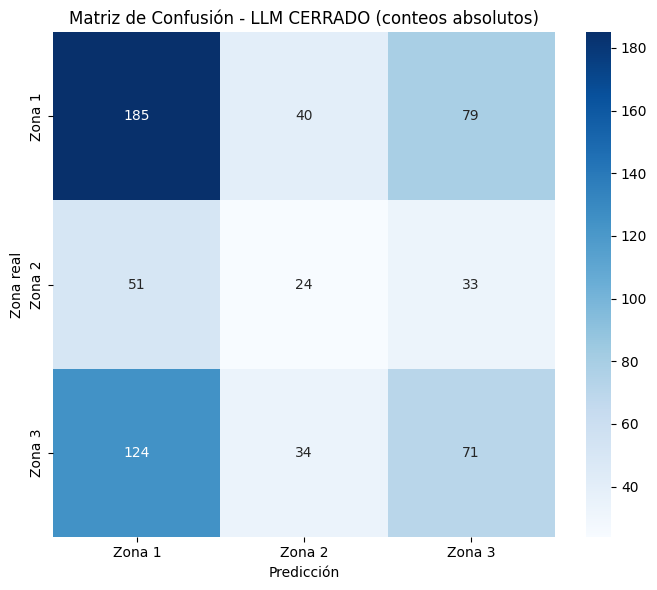

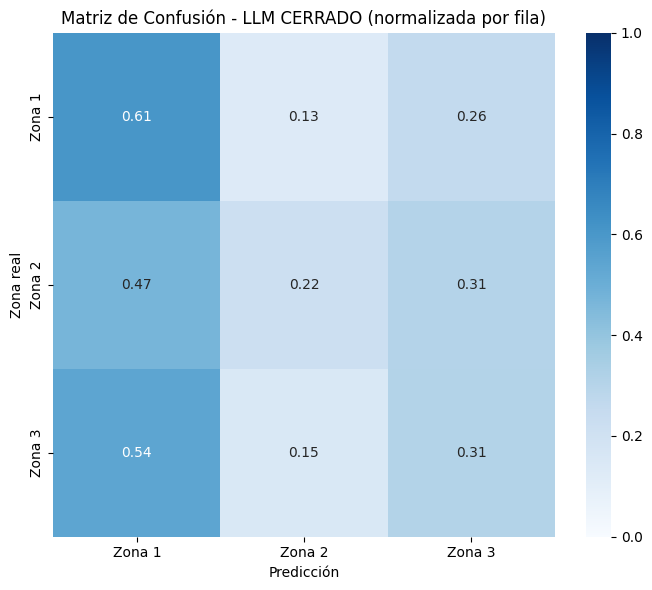

In [3]:
evaluador = EvaluadorResultados()
evaluador.evaluar("predicciones_finales_cerrado.csv", "cerrado")

Resultados PROMPT ABIERTO 1, uso de la primera version abierta del VLM y prompt abierto del LLM


 EVALUACION MULTICLASE (ZONAS 1, 2 Y 3) 
Muestras evaluadas:           615
Accuracy:                     46.83%
Balanced accuracy:            38.91%
Precision macro:              39.05%
Recall macro:                 38.91%
F1 macro:                     37.19%
F1 weighted:                  44.42%
Predicciones no válidas:      26

Resumen detallado de las predicciones:
      vid_ID kicker_foot  zona_real prediccion_etiqueta  prediccion_numero  acierto
  v1_p1_diag     derecha          1             ABIERTO                  3    False
  v1_p2_diag     derecha          1             CENTRAL                  2    False
  v1_p3_diag     derecha          2             CRUZADO                  1    False
  v1_p4_diag     derecha          3             CRUZADO                  1    False
  v1_p5_diag     derecha          1             ABIERTO                  3    False
  v1_p6_diag     derecha          1             ABIERTO                  3    False
  v1_p7_diag     derecha          3      

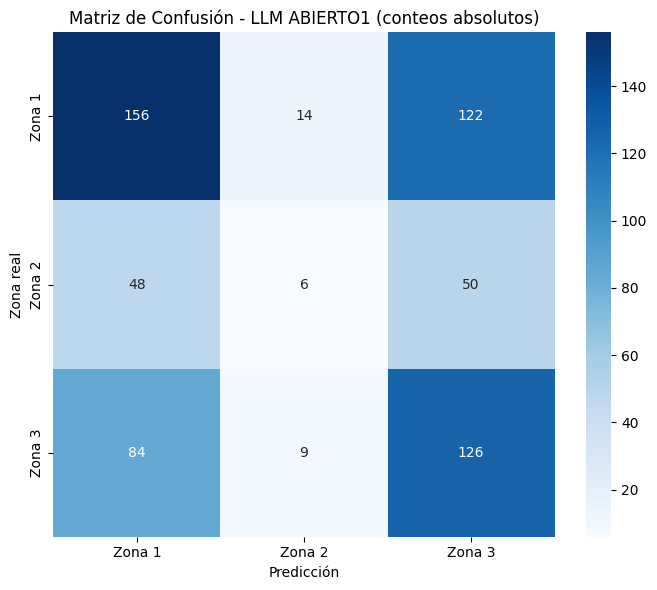

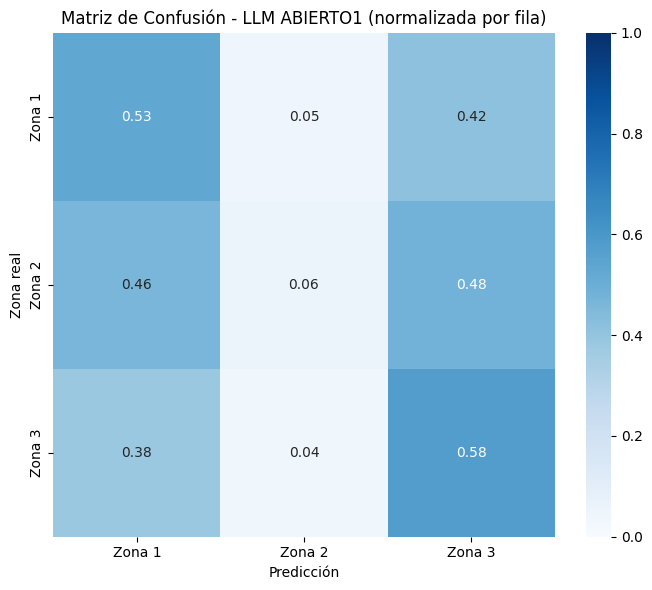

In [4]:
evaluador = EvaluadorResultados()
evaluador.evaluar("predicciones_finales_abierto1.csv", "abierto1")

Resultados PROMPT ABIERTO 2, uso de la segunda version abierta del VLM y prompt abierto del LLM


 EVALUACION MULTICLASE (ZONAS 1, 2 Y 3) 
Muestras evaluadas:           638
Accuracy:                     49.69%
Balanced accuracy:            40.28%
Precision macro:              39.77%
Recall macro:                 40.28%
F1 macro:                     38.45%
F1 weighted:                  46.69%
Predicciones no válidas:      3

Resumen detallado de las predicciones:
      vid_ID kicker_foot  zona_real prediccion_etiqueta  prediccion_numero  acierto
  v1_p1_diag     derecha          1             CRUZADO                  1     True
  v1_p2_diag     derecha          1             CRUZADO                  1     True
  v1_p3_diag     derecha          2             CRUZADO                  1    False
  v1_p4_diag     derecha          3             CRUZADO                  1    False
  v1_p5_diag     derecha          1             CRUZADO                  1     True
  v1_p6_diag     derecha          1             ABIERTO                  3    False
  v1_p7_diag     derecha          3       

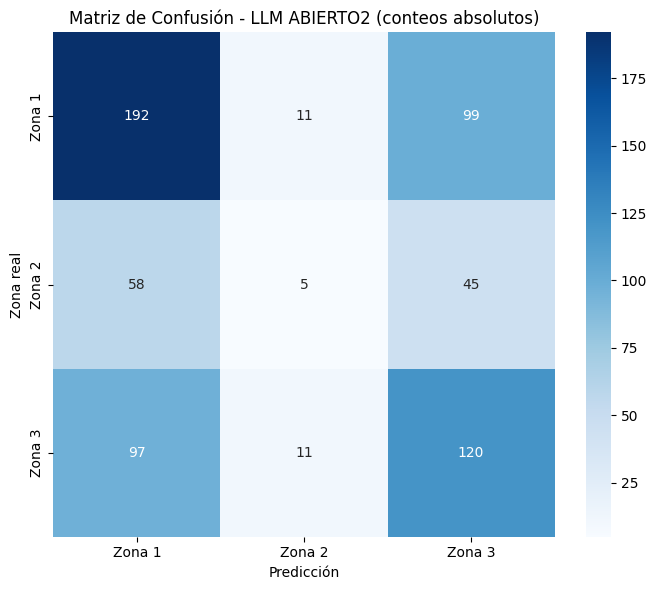

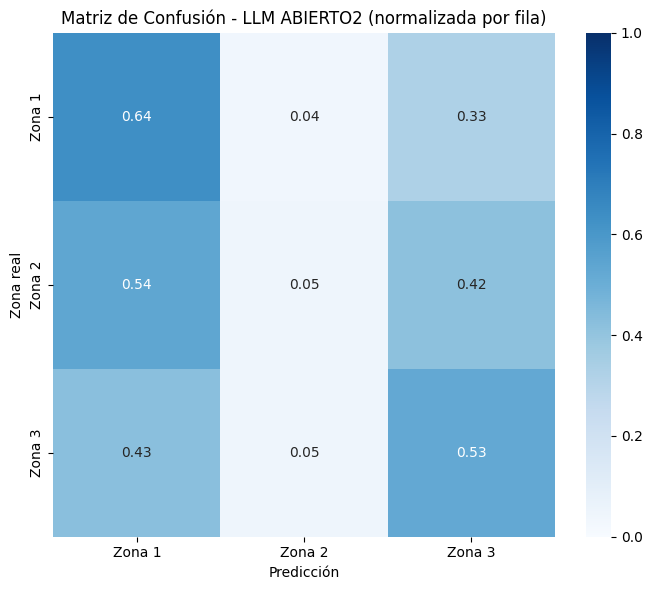

In [5]:
evaluador = EvaluadorResultados()
evaluador.evaluar("predicciones_finales_abierto2.csv", "abierto2")

### 10. Análisis Comparativo: Unificación Visual de Matrices de Confusión

Para presentar y comparar visualmente el rendimiento de las dos variantes abiertas diseñadas en esta segunda iteración, se reutilizó de forma íntegra el bloque de código de unificación implementado en la fase analítica anterior. Al conservar intacta la misma lógica de carga robusta, el cruce estricto de datos con la verdad base, la traducción espacial de la lateralidad y la normalización probabilística por fila, se asegura que la evaluación comparativa sea metodológicamente equivalente. Las únicas modificaciones introducidas en este módulo radican en la actualización de las rutas de los archivos de entrada para leer las nuevas predicciones generadas y en el ajuste dinámico de los títulos de renderizado, permitiendo así proyectar frente a frente los mapas de calor de ambos enfoques macro-gestuales en un único lienzo gráfico de alta resolución.

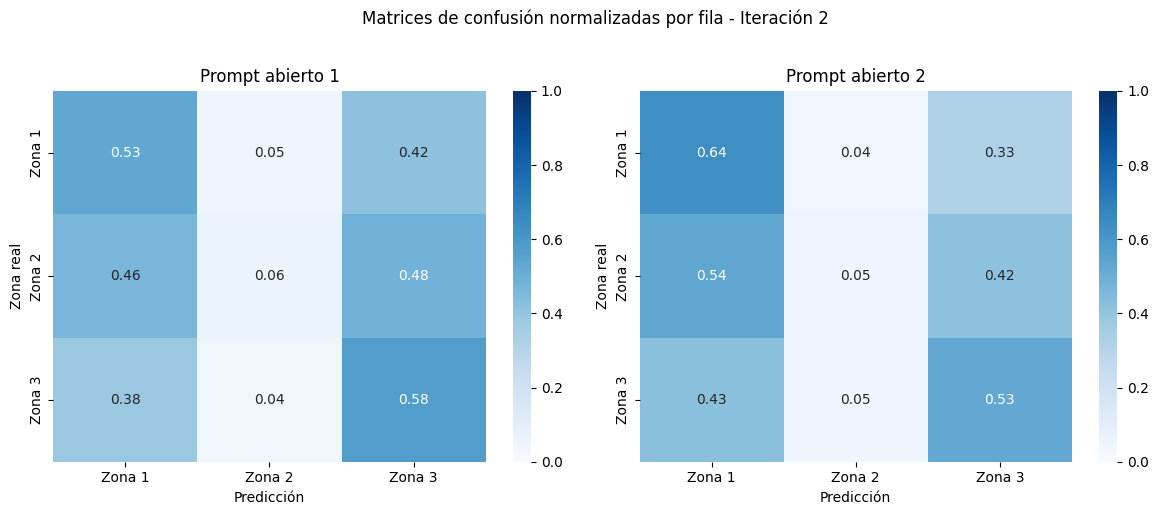

In [5]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

PRED_PATH_ABIERTO = "predicciones_finales_abierto1.csv"
PRED_PATH_CERRADO = "predicciones_finales_abierto2.csv"
LABELS_PATH = "labeled_frames_grouped.csv"


def cargar_labels(labels_path):
    if not os.path.exists(labels_path):
        raise FileNotFoundError(f"No se ha encontrado '{labels_path}'")

    df_labels = pd.read_csv(labels_path)

    cols_labels_necesarias = {"vid_ID", "shoot_zone_grouped"}
    faltan_labels = cols_labels_necesarias - set(df_labels.columns)
    if faltan_labels:
        raise ValueError(f"Faltan columnas en labeled_frames_grouped.csv: {sorted(faltan_labels)}")

    df_labels = df_labels[["vid_ID", "shoot_zone_grouped"]].dropna().copy()
    df_labels["shoot_zone_grouped"] = df_labels["shoot_zone_grouped"].astype(int)

    inconsistencias = (
        df_labels.groupby("vid_ID")["shoot_zone_grouped"]
        .nunique()
        .reset_index(name="n_zonas_distintas")
    )
    inconsistencias = inconsistencias[inconsistencias["n_zonas_distintas"] > 1]

    if not inconsistencias.empty:
        ejemplos = inconsistencias["vid_ID"].astype(str).tolist()[:10]
        raise ValueError(
            "Hay videos con más de una zona real distinta en labeled_frames_grouped.csv. "
            f"Ejemplos: {ejemplos}"
        )

    df_labels = (
        df_labels.drop_duplicates(subset=["vid_ID"])
        .rename(columns={"shoot_zone_grouped": "zona_real"})
        .copy()
    )

    return df_labels


def mapear_a_numero(row):
    pred = str(row["prediccion_etiqueta"]).strip().upper()
    pierna = str(row["kicker_foot"]).strip().lower()

    if pred in ["CENTRAL", "CENTRO"]:
        return 2

    if pierna == "derecha":
        if pred == "CRUZADO":
            return 1
        if pred == "ABIERTO":
            return 3

    elif pierna == "izquierda":
        if pred == "CRUZADO":
            return 3
        if pred == "ABIERTO":
            return 1

    return -1


def preparar_df_pred(path_pred, df_labels):
    if not os.path.exists(path_pred):
        raise FileNotFoundError(f"No se ha encontrado '{path_pred}'")

    df_pred = pd.read_csv(path_pred)

    cols_pred_necesarias = {"vid_ID", "kicker_foot", "prediccion_etiqueta"}
    faltan_pred = cols_pred_necesarias - set(df_pred.columns)
    if faltan_pred:
        raise ValueError(f"Faltan columnas en {path_pred}: {sorted(faltan_pred)}")

    df = df_pred.merge(df_labels, on="vid_ID", how="inner")

    if df.empty:
        raise ValueError(f"El merge entre {path_pred} y las labels ha dado 0 filas.")

    df = df[df["zona_real"].isin([1, 2, 3])].copy()
    df["prediccion_numero"] = df.apply(mapear_a_numero, axis=1)
    df_validos = df[df["prediccion_numero"].isin([1, 2, 3])].copy()

    if df_validos.empty:
        raise ValueError(f"No hay predicciones válidas en {path_pred}")

    return df_validos


df_labels = cargar_labels(LABELS_PATH)
df_abierto = preparar_df_pred(PRED_PATH_ABIERTO, df_labels)
df_cerrado = preparar_df_pred(PRED_PATH_CERRADO, df_labels)

labels = [1, 2, 3]
nombres_clases = ["Zona 1", "Zona 2", "Zona 3"]

cm_abierto = confusion_matrix(df_abierto["zona_real"], df_abierto["prediccion_numero"], labels=labels)
cm_cerrado = confusion_matrix(df_cerrado["zona_real"], df_cerrado["prediccion_numero"], labels=labels)

cm_abierto_norm = cm_abierto.astype(float) / cm_abierto.sum(axis=1, keepdims=True)
cm_cerrado_norm = cm_cerrado.astype(float) / cm_cerrado.sum(axis=1, keepdims=True)

cm_abierto_norm = np.nan_to_num(cm_abierto_norm)
cm_cerrado_norm = np.nan_to_num(cm_cerrado_norm)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(
    cm_abierto_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=nombres_clases,
    yticklabels=nombres_clases,
    vmin=0,
    vmax=1,
    ax=axes[0]
)
axes[0].set_title("Prompt abierto 1")
axes[0].set_xlabel("Predicción")
axes[0].set_ylabel("Zona real")

sns.heatmap(
    cm_cerrado_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=nombres_clases,
    yticklabels=nombres_clases,
    vmin=0,
    vmax=1,
    ax=axes[1]
)
axes[1].set_title("Prompt abierto 2")
axes[1].set_xlabel("Predicción")
axes[1].set_ylabel("Zona real")

plt.suptitle("Matrices de confusión normalizadas por fila - Iteración 2", y=1.02)
plt.tight_layout()
plt.savefig("matrices_confusion_iteracion1_comparativa.png", dpi=300, bbox_inches="tight")
plt.show()
